<a href="https://colab.research.google.com/github/nguyenvandungds/Hotel-Room-Price-Recommendation-System-using-CatBoost/blob/main/Hotel-Room-Price-Recommendation-System-using-CatBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <h1 style="background-color:skyblue; font-family:newtimeroman; font-size:250%; text-align:center; border-radius: 15px 50px;"></h1:>

<h1 style="font-family:verdana;"> <center> ỨNG DỤNG THUẬT TOÁN CATBOOST XÂY DỰNG MÔ HÌNH DỰ ĐOÁN GIÁ PHÒNG THEO CÔNG SUẤT 📝 </center> </h1>
<p><center style="color:#159364; font-family:cursive;"> KHÓA LUẬN TỐT NGHIỆP </p>

***

**Phân tích, xử lý dữ liệu khách sạn, dự đoán giá phòng sử dụng mô hình CatBoost**

# Bảng nội dung
1. Cài đặt và nhập các thư viện cần thiết và đọc dữ liệu từ file
2. Phân tích và xử lý dữ liệu
3. Đọc dữ liệu đã được chuẩn hóa từ file
4. Xây dựng và đánh giá mô hình
5. So sánh với giá phòng của các khách sạn bán kính 1 km và đưa ra giá phòng gợi ý cho khách sạn
6. Kết luận

Kết nối với Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Cài đặt và nhập các thư viện cần thiết và đọc dữ liệu từ file

1.1. Cài đặt các thư viện cần thiết

In [ ]:
pip install --upgrade --force-reinstall numpy scipy pandas scikit-learn

  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached scipy-1.15.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-2.2.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (89 kB)
  Using cached scikit_learn-1.6.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached joblib-1.5.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
Using cached scipy-1.15.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014

In [ ]:
!pip install CatBoost

1.2. Nhập các thư viện cần thiết

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

1.3. Đọc dữ liệu từ file

In [ ]:
file_path = '/content/drive/My Drive/Data/Tulip3.xlsx'
df = pd.read_excel(file_path, sheet_name="Data", engine="openpyxl")
print(df.shape)
df.head()

(13255, 40)


,Date,RoomType,Total,OCC(%),Day,Month,Year,WeekDay,Is_weekend,Is_holiday,...,Towel,Room/Wardrobe,Desk,Balcony/Porch,InteriorWindow,Balcony,Sofa,Coffee/TeaMakingTools,NoWindows,FullyEquipped
0,2023-01-01,Deluxe Twin,2325600.0,73.333333,1,1,2023,Sunday,1,1,...,1,1,1,0,0,0,0,0,0,0
1,2023-01-01,Executive Twin,820000.0,73.333333,1,1,2023,Sunday,1,1,...,1,1,0,1,0,0,0,0,0,0
2,2023-01-01,Deluxe Twin,770000.0,73.333333,1,1,2023,Sunday,1,1,...,1,1,1,0,0,0,0,0,0,0
3,2023-01-01,Superior Double,640000.0,73.333333,1,1,2023,Sunday,1,1,...,1,1,1,0,1,0,0,0,0,0
4,2023-01-01,Deluxe Twin,1450000.0,73.333333,1,1,2023,Sunday,1,1,...,1,1,1,0,0,0,0,0,0,0


In [ ]:
# Chuyển định dạng ngày
df['Date'] = pd.to_datetime(df['Date'])

# Sắp xếp theo Room Type và Date để thuận tiện xử lý
df.sort_values(by=['RoomType', 'Date'], inplace=True)

# Danh sách lưu kết quả
past_avg_prices = []
past_avg_occupancy = []

# Duyệt từng dòng
for idx, row in df.iterrows():
    current_date = row['Date']
    room_type = row['RoomType']

    # Lọc các dòng quá khứ cùng loại phòng
    mask = (df['RoomType'] == room_type) & (df['Date'] < current_date)
    past_rows = df[mask]

    if not past_rows.empty:
        # Tìm ngày gần nhất trong quá khứ
        last_date = past_rows['Date'].max()

        # Lấy tất cả dòng cùng Room Type tại ngày đó
        same_day_rows = df[(df['RoomType'] == room_type) & (df['Date'] == last_date)]

        # Tính trung bình
        avg_price = same_day_rows['Total'].mean()
        avg_occupancy = same_day_rows['OCC(%)'].mean()
    else:
        # Không có dữ liệu quá khứ → lấy giá trị tại dòng hiện tại
        avg_price = row['Total']
        avg_occupancy = row['OCC(%)']

    past_avg_prices.append(avg_price)
    past_avg_occupancy.append(avg_occupancy)

# Gán vào DataFrame
df['PastPrices'] = past_avg_prices
df['PastOCC'] = past_avg_occupancy

In [ ]:
df.to_excel('DataKS.xlsx')

# 2. Phân tích và xử lý dữ liệu

2.1. Xem thông tin chung về dữ liệu

RoomType
Superior Double     4345
Deluxe Double       3684
Deluxe Twin         3151
Suite Double         886
Executive Double     533
Executive Twin       419
Standard Double      197
Premium Double        23
Premium Twin          17
Name: count, dtype: int64


Text(0.5, 1.0, 'Biểu đồ đặt phòng theo loại phòng')

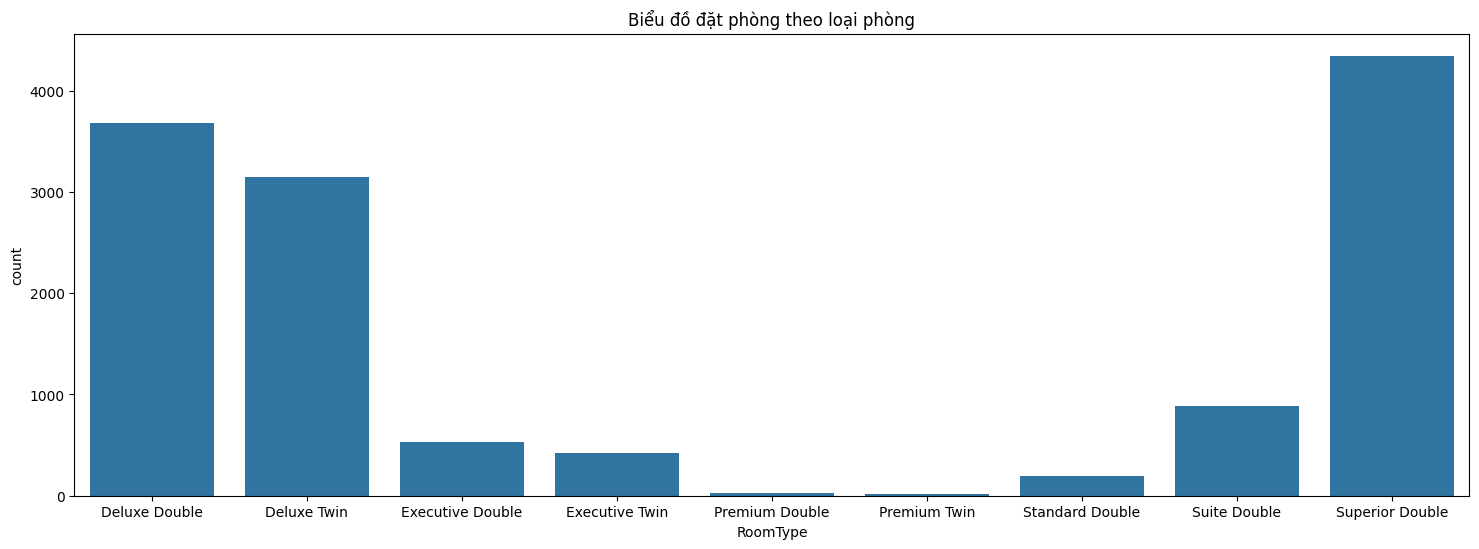

In [ ]:
print(df.RoomType.value_counts())
plt.figure(figsize=(18,6))
sns.countplot(x='RoomType', data= df).set_title("Biểu đồ đặt phòng theo loại phòng")

Month
2     1879
1     1559
6     1457
7     1398
3     1273
8     1203
4     1080
5     1037
12     808
10     551
9      547
11     463
Name: count, dtype: int64


Text(0.5, 1.0, 'Biểu đồ đặt phòng theo tháng')

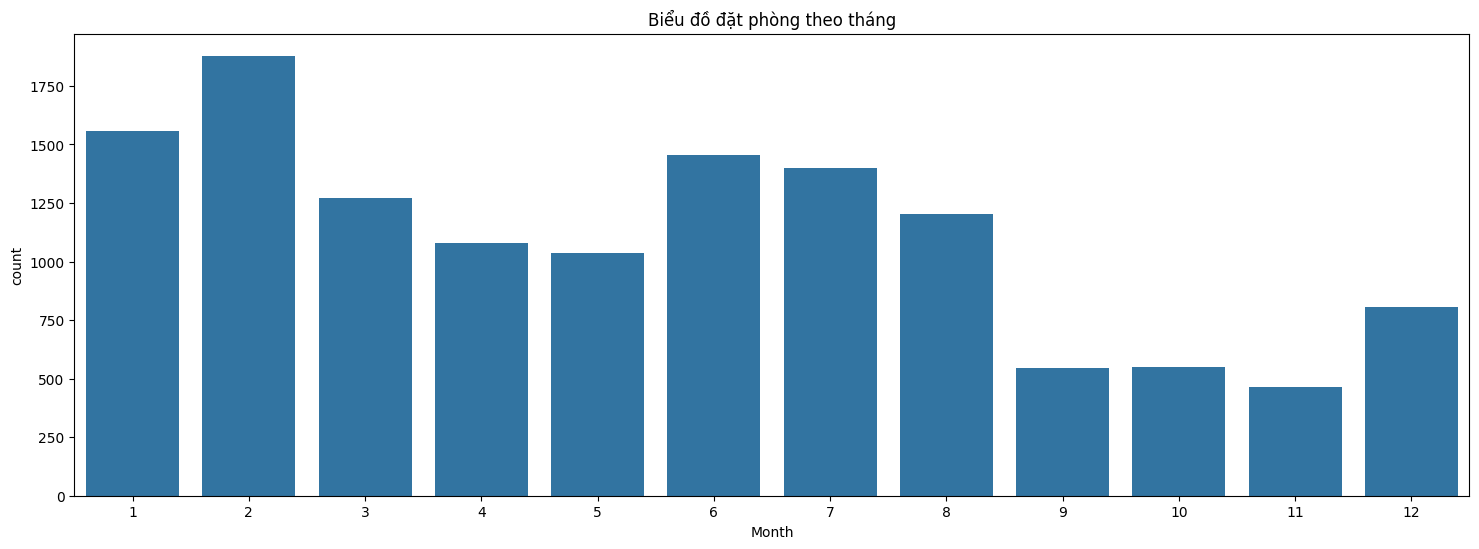

In [ ]:
print(df.Month.value_counts())
plt.figure(figsize=(18,6))
sns.countplot(x='Month', data= df).set_title("Biểu đồ đặt phòng theo tháng")

Day
1     500
24    478
11    471
22    465
3     460
2     454
23    451
10    445
4     444
15    444
12    442
25    434
13    434
26    430
9     427
7     426
27    426
19    425
21    422
16    421
28    420
20    420
8     419
14    417
29    417
6     415
18    405
5     398
30    394
17    373
31    278
Name: count, dtype: int64


Text(0.5, 1.0, 'Biểu đồ đặt phòng theo ngày trong tuần')

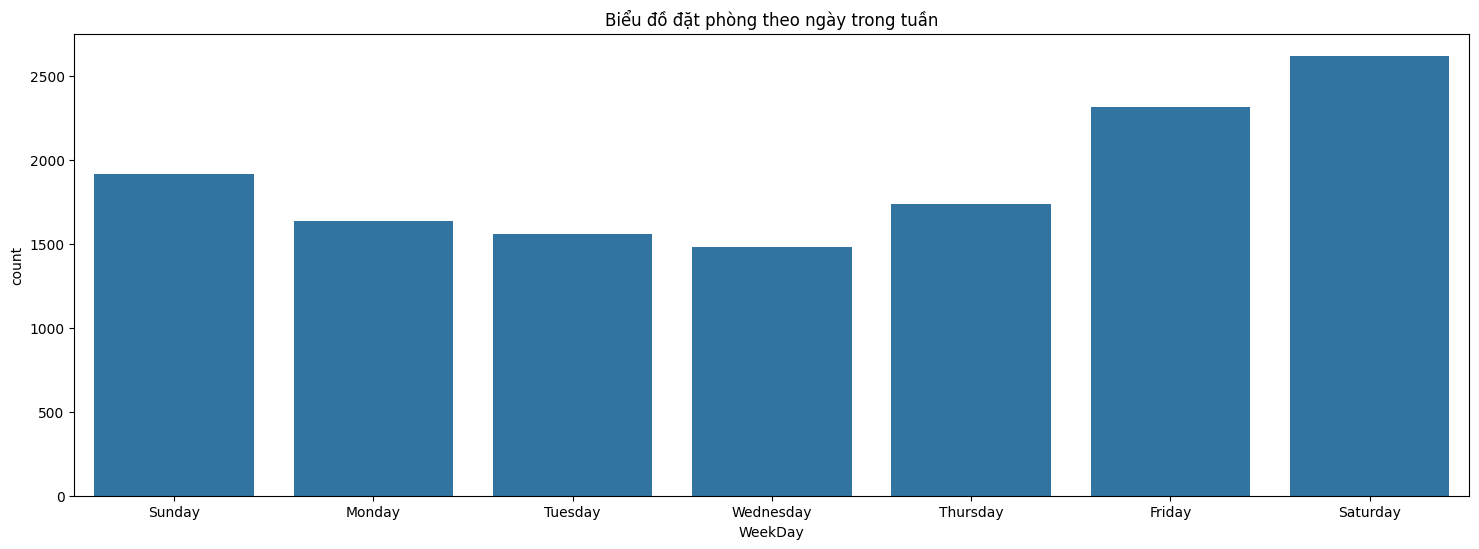

In [ ]:
print(df.Day.value_counts())
plt.figure(figsize=(18,6))
sns.countplot(x='WeekDay', data= df).set_title("Biểu đồ đặt phòng theo ngày trong tuần")

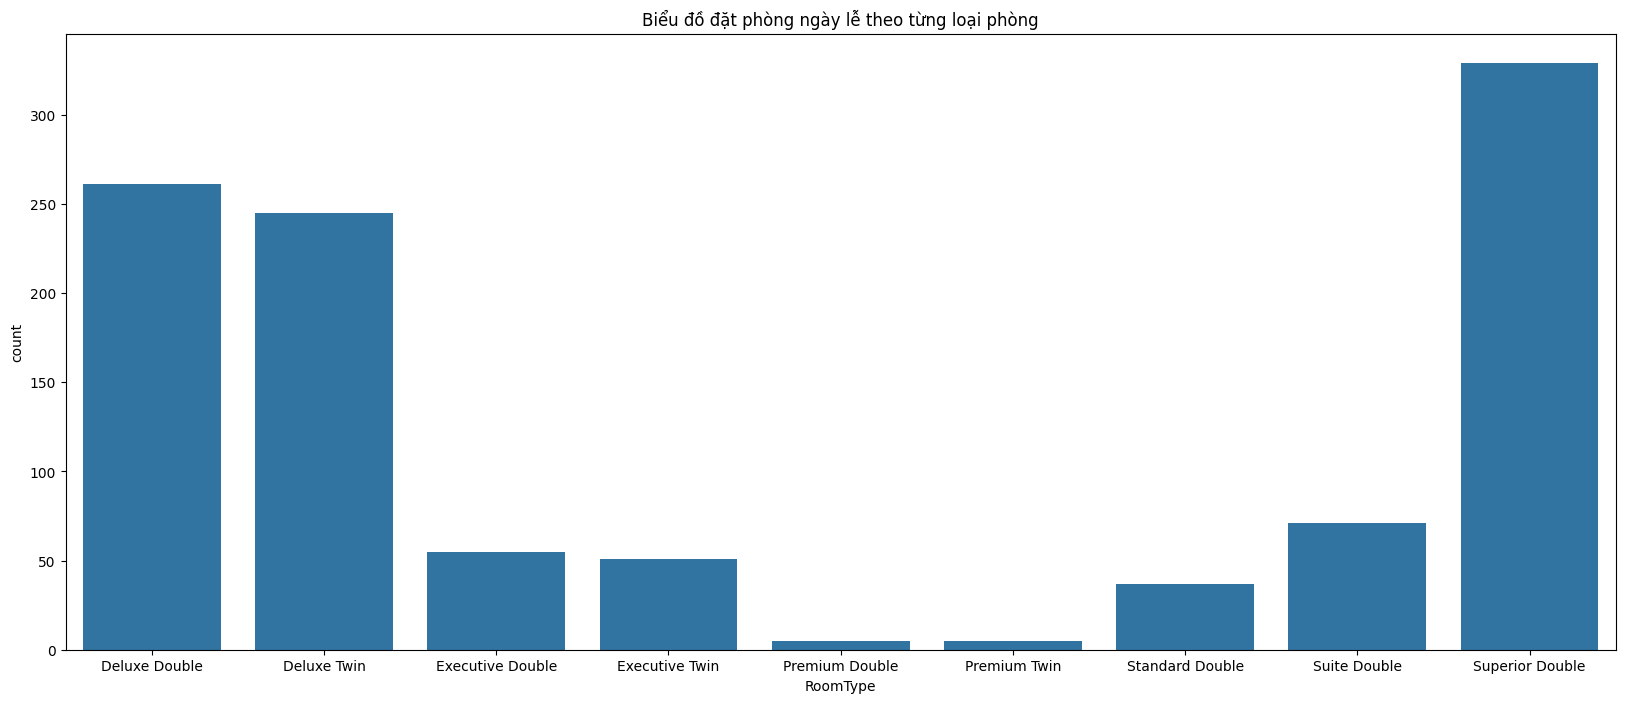

In [ ]:
plt.figure(figsize=(20,8))
sns.countplot(x='RoomType', data=df[df['Is_holiday'] == 1]).set_title("Biểu đồ đặt phòng ngày lễ theo từng loại phòng")
plt.show()

Text(0.5, 1.0, 'Biểu đồ đặt phòng theo nhóm của hai cột ngày trong tuần và loại phòng.')

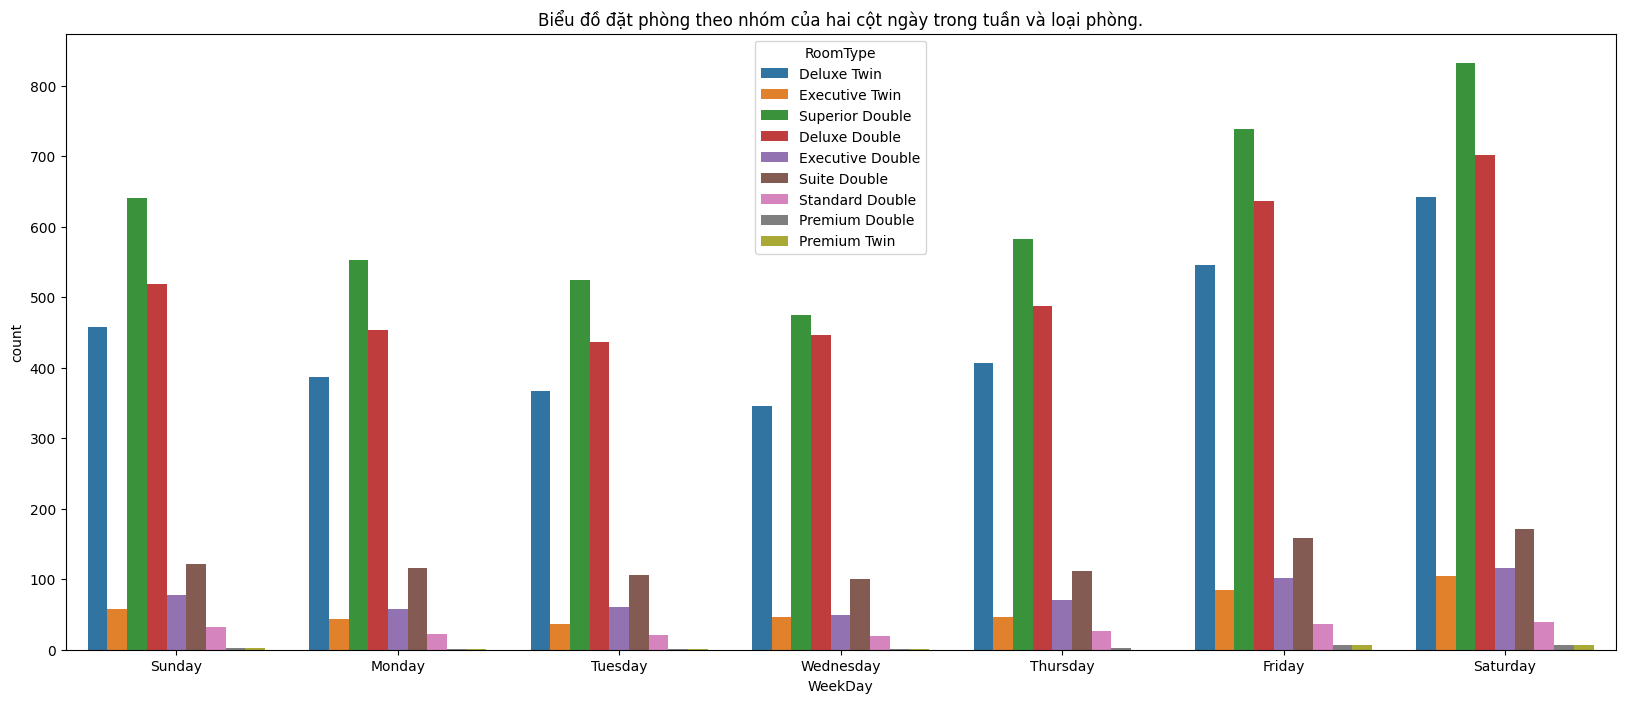

In [ ]:
plt.figure(figsize=(20,8))
sns.countplot(x='WeekDay', hue='RoomType', data= df).set_title("Biểu đồ đặt phòng theo nhóm của hai cột ngày trong tuần và loại phòng.")

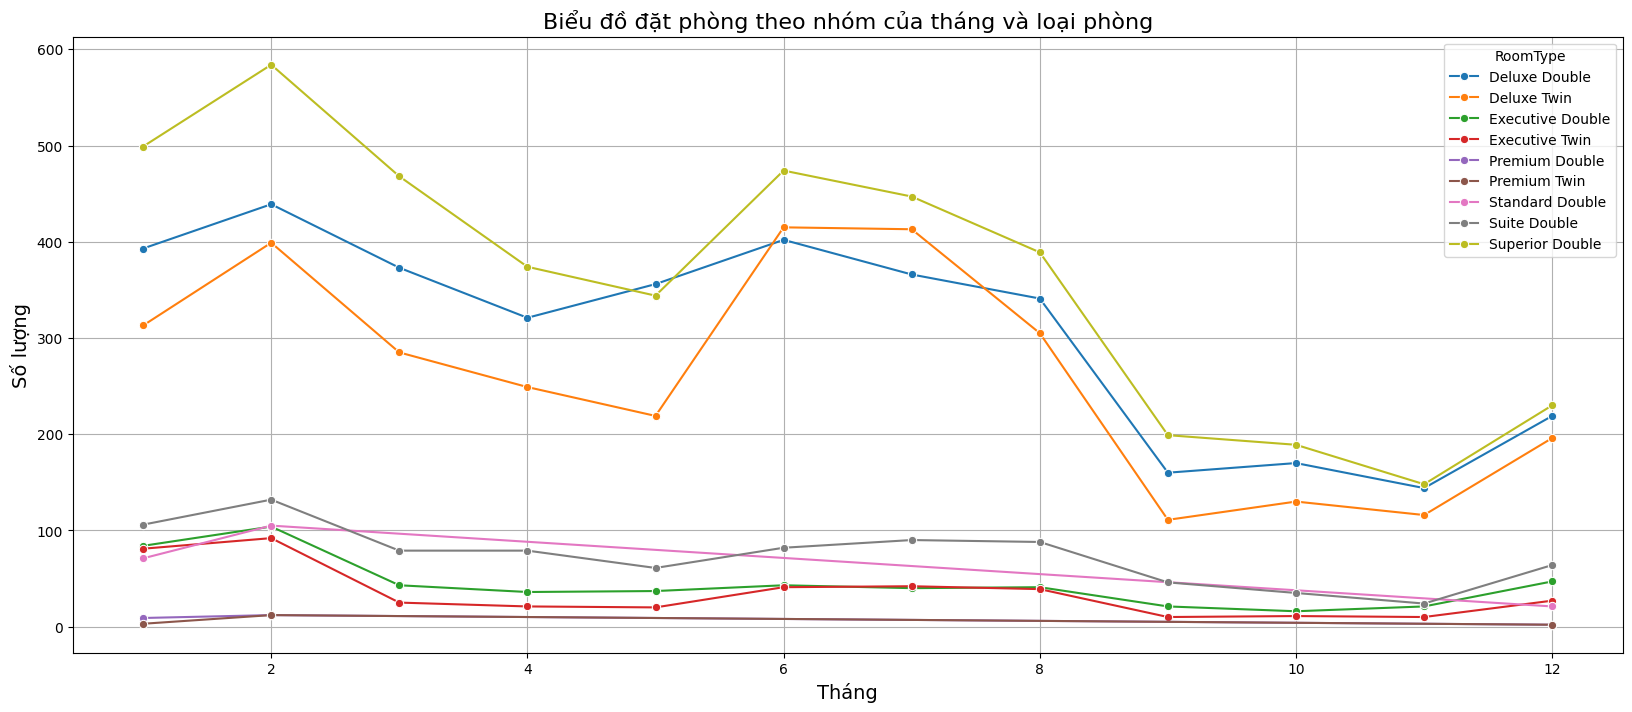

In [ ]:
# Giả sử df là DataFrame gốc
# Bước 1: Nhóm dữ liệu theo Month và RoomType rồi đếm số lượng
grouped_df = df.groupby(['Month', 'RoomType']).size().reset_index(name='Count')

# Bước 2: Vẽ biểu đồ đường
plt.figure(figsize=(20, 8))
sns.lineplot(data=grouped_df, x='Month', y='Count', hue='RoomType', marker='o')

# Tiêu đề
plt.title("Biểu đồ đặt phòng theo nhóm của tháng và loại phòng", fontsize=16)
plt.xlabel("Tháng", fontsize=14)
plt.ylabel("Số lượng", fontsize=14)
plt.grid(True)
plt.show()


In [ ]:
print(f"Dữ liệu bao gồm {df.shape[0]} dòng và {df.shape[1]} cột")
print("------------------------------------------------------------")
df.info()

Dữ liệu bao gồm 13255 dòng và 61 cột
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 13255 entries, 6 to 13249
Data columns (total 61 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       13255 non-null  datetime64[ns]
 1   Total                      13255 non-null  float64       
 2   OCC(%)                     13255 non-null  float64       
 3   Day                        13255 non-null  int64         
 4   Year                       13255 non-null  int64         
 5   WeekDay                    13255 non-null  int64         
 6   Is_weekend                 13255 non-null  int64         
 7   Is_holiday                 13255 non-null  int64         
 8   RoomArea(m2)               13255 non-null  int64         
 9   Bathroom-shower            13255 non-null  int64         
 10  CeilingFan                 13255 non-

In [ ]:
import pandas as pd

# Tạo DataFrame ví dụ (bạn thay bằng df thật của bạn)
# df = pd.read_csv("...")

# Tạo bảng chứa thông tin từ df.info()
info_data = {
    "Tên cột": df.columns,
    "Số lượng không null": df.notnull().sum().values,
    "Kiểu dữ liệu": df.dtypes.values
}

info_df = pd.DataFrame(info_data)

# Ghi vào file Excel
info_df.to_excel("thong_tin_dataframe.xlsx", index=False)

Tên các cột của dữ liệu

In [ ]:
df.columns

Index(['Date', 'Total', 'OCC(%)', 'Day', 'Year', 'WeekDay', 'Is_weekend',
       'Is_holiday', 'RoomArea(m2)', 'Bathroom-shower', 'CeilingFan',
       'DailyMineralWater', 'DressingTable', 'PowerConverter', 'OutsideWindow',
       'HairDryer', 'HotWater', 'Safe', 'InternetAccessViaWiFi',
       'BedSheets-pillows', 'MiniFridge', 'Minibar', 'Non-SmokingRooms',
       'Shower', 'Cable/SatelliteTV', 'TableLamp', 'Phone',
       'BathroomAccessories', 'Towel', 'Room/Wardrobe', 'Desk',
       'Balcony/Porch', 'InteriorWindow', 'Balcony', 'Sofa',
       'Coffee/TeaMakingTools', 'NoWindows', 'FullyEquipped', 'PastPrices',
       'PastOCC', 'RoomType_Deluxe Double', 'RoomType_Deluxe Twin',
       'RoomType_Executive Double', 'RoomType_Executive Twin',
       'RoomType_Premium Double', 'RoomType_Premium Twin',
       'RoomType_Standard Double', 'RoomType_Suite Double',
       'RoomType_Superior Double', 'Month_1', 'Month_2', 'Month_3', 'Month_4',
       'Month_5', 'Month_6', 'Month_7', 'Month_8

2.2. Kiểm tra dữ liệu missing

In [ ]:
# Hàm missing_data tính toán số lượng
# và tỷ lệ phần trăm của các giá trị thiếu trong bộ dữ liệu.
def missing_data(data):
    # Tổng số giá trị thiếu được tính toán và sắp xếp theo thứ tự giảm dần.
    total = data.isnull().sum().sort_values(ascending = False)
    # Tỷ lệ phần trăm của các giá trị thiếu được tính toán và sắp xếp theo thứ tự giảm dần.
    percent = (data.isnull().sum()/data.isnull().count()*100).sort_values(ascending = False)
    # Kết quả trả về bao gồm tổng số giá trị thiếu và tỷ lệ phần trăm của chúng.
    return pd.concat([total, percent], axis=1, keys=['total','percent'])

# Gọi hàm missing_data và truyền vào đối số data
# để tính toán số lượng và tỷ lệ phần trăm các giá trị thiếu trong dữ liệu.
missing_data(df)

,total,percent
Date,0,0.0
Total,0,0.0
OCC(%),0,0.0
Day,0,0.0
Year,0,0.0
...,...,...
Month_8,0,0.0
Month_9,0,0.0
Month_10,0,0.0
Month_11,0,0.0


2.3. Chuẩn hóa dữ liệu

Loại phòng

In [ ]:
df_encoded = pd.get_dummies(df, columns=['RoomType'])
roomtype_cols = [col for col in df_encoded.columns if col.startswith('RoomType')]
df_encoded[roomtype_cols] = df_encoded[roomtype_cols].astype(int)
df = df_encoded
df

,Date,Total,OCC(%),Day,Month,Year,WeekDay,Is_weekend,Is_holiday,RoomArea(m2),...,PastOCC,RoomType_Deluxe Double,RoomType_Deluxe Twin,RoomType_Executive Double,RoomType_Executive Twin,RoomType_Premium Double,RoomType_Premium Twin,RoomType_Standard Double,RoomType_Suite Double,RoomType_Superior Double
6,2023-01-01,1100000.0,73.333333,1,1,2023,Sunday,1,1,20,...,73.333333,1,0,0,0,0,0,0,0,0
13,2023-01-01,764235.0,73.333333,1,1,2023,Sunday,1,1,20,...,73.333333,1,0,0,0,0,0,0,0,0
25,2023-01-02,400000.0,36.666667,2,1,2023,Monday,0,0,20,...,73.333333,1,0,0,0,0,0,0,0,0
26,2023-01-02,400000.0,36.666667,2,1,2023,Monday,0,0,20,...,73.333333,1,0,0,0,0,0,0,0,0
33,2023-01-03,528986.0,56.666667,3,1,2023,Tuesday,0,0,20,...,36.666667,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13229,2025-02-24,617500.0,33.333333,24,2,2025,Monday,0,0,20,...,50.000000,0,0,0,0,0,0,0,0,1
13245,2025-02-26,600000.0,40.000000,26,2,2025,Wednesday,0,0,20,...,33.333333,0,0,0,0,0,0,0,0,1
13247,2025-02-26,571162.0,40.000000,26,2,2025,Wednesday,0,0,20,...,33.333333,0,0,0,0,0,0,0,0,1
13248,2025-02-26,571162.0,40.000000,26,2,2025,Wednesday,0,0,20,...,33.333333,0,0,0,0,0,0,0,0,1


Ngày trong tuần

In [ ]:
# Khởi tạo một dictionary gán nhãn cho từng nhóm ngày
label = {
    'Monday':2,
    'Tuesday':3,
    'Wednesday':4,
    'Thursday':5,
    'Friday':6,
    'Saturday':7,
    'Sunday':8
}

# Sử dụng phương thức map để ánh xạ nhãn từ dictionary 'label'
# vào cột 'Day' của tập dữ liệu 'df'
df['WeekDay'] = df['WeekDay'].map(label)

In [ ]:
df_encoded = pd.get_dummies(df, columns=['Month'])
month_cols = [col for col in df_encoded.columns if col.startswith('Month')]
df_encoded[month_cols] = df_encoded[month_cols].astype(int)
df = df_encoded
df

,Date,Total,OCC(%),Day,Year,WeekDay,Is_weekend,Is_holiday,RoomArea(m2),Bathroom-shower,...,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
6,2023-01-01,1100000.0,73.333333,1,2023,8,1,1,20,1,...,0,0,0,0,0,0,0,0,0,0
13,2023-01-01,764235.0,73.333333,1,2023,8,1,1,20,1,...,0,0,0,0,0,0,0,0,0,0
25,2023-01-02,400000.0,36.666667,2,2023,2,0,0,20,1,...,0,0,0,0,0,0,0,0,0,0
26,2023-01-02,400000.0,36.666667,2,2023,2,0,0,20,1,...,0,0,0,0,0,0,0,0,0,0
33,2023-01-03,528986.0,56.666667,3,2023,3,0,0,20,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13229,2025-02-24,617500.0,33.333333,24,2025,2,0,0,20,1,...,0,0,0,0,0,0,0,0,0,0
13245,2025-02-26,600000.0,40.000000,26,2025,4,0,0,20,1,...,0,0,0,0,0,0,0,0,0,0
13247,2025-02-26,571162.0,40.000000,26,2025,4,0,0,20,1,...,0,0,0,0,0,0,0,0,0,0
13248,2025-02-26,571162.0,40.000000,26,2025,4,0,0,20,1,...,0,0,0,0,0,0,0,0,0,0


2.4. Lưu dữ liệu đã được chuẩn hóa

In [ ]:
data_Export = df[['Date', 'RoomType_Deluxe Twin', 'RoomType_Executive Twin', 'RoomType_Superior Double', 'RoomType_Deluxe Double', 'RoomType_Executive Double', 'RoomType_Suite Double', 'RoomType_Standard Double', 'RoomType_Premium Double', 'RoomType_Premium Twin',
       'Total', 'OCC(%)', 'Day', 'Month_1', 'Month_2', 'Month_3', 'Month_4',
       'Month_5', 'Month_6', 'Month_7', 'Month_8', 'Month_9', 'Month_10',
       'Month_11', 'Month_12', 'Year',
       'WeekDay', 'Is_weekend', 'Is_holiday', 'RoomArea(m2)',
       'Bathroom-shower', 'CeilingFan', 'DailyMineralWater', 'DressingTable',
       'PowerConverter', 'OutsideWindow', 'HairDryer', 'HotWater', 'Safe',
       'InternetAccessViaWiFi', 'BedSheets-pillows', 'MiniFridge', 'Minibar',
       'Non-SmokingRooms', 'Shower', 'Cable/SatelliteTV', 'TableLamp', 'Phone',
       'BathroomAccessories', 'Towel', 'Room/Wardrobe', 'Desk',
       'Balcony/Porch', 'InteriorWindow', 'Balcony', 'Sofa',
       'Coffee/TeaMakingTools', 'NoWindows', 'FullyEquipped']]
data_Export.to_excel('Data_chuan_hoa.xlsx')

# 3. Đọc dữ liệu đã được chuẩn hóa từ file

In [ ]:
data_ch = pd.read_excel('Data_chuan_hoa.xlsx', index_col=0)

# In thông tin về cấu trúc dữ liệu DataFrame 'data_ch'
data_ch.info()

# Hiển thị 5 dòng đầu tiên của DataFrame 'data_ch'
data_ch.head(100)

<class 'pandas.core.frame.DataFrame'>
Index: 13255 entries, 0 to 13254
Data columns (total 59 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       13255 non-null  datetime64[ns]
 1   RoomType_Deluxe Twin       13255 non-null  int64         
 2   RoomType_Executive Twin    13255 non-null  int64         
 3   RoomType_Superior Double   13255 non-null  int64         
 4   RoomType_Deluxe Double     13255 non-null  int64         
 5   RoomType_Executive Double  13255 non-null  int64         
 6   RoomType_Suite Double      13255 non-null  int64         
 7   RoomType_Standard Double   13255 non-null  int64         
 8   RoomType_Premium Double    13255 non-null  int64         
 9   RoomType_Premium Twin      13255 non-null  int64         
 10  Total                      13255 non-null  float64       
 11  OCC(%)                     13255 non-null  float64       
 12  Day      

,Date,RoomType_Deluxe Twin,RoomType_Executive Twin,RoomType_Superior Double,RoomType_Deluxe Double,RoomType_Executive Double,RoomType_Suite Double,RoomType_Standard Double,RoomType_Premium Double,RoomType_Premium Twin,...,Towel,Room/Wardrobe,Desk,Balcony/Porch,InteriorWindow,Balcony,Sofa,Coffee/TeaMakingTools,NoWindows,FullyEquipped
0,2023-01-01,1,0,0,0,0,0,0,0,0,...,1,1,1,0,0,0,0,0,0,0
1,2023-01-01,0,1,0,0,0,0,0,0,0,...,1,1,0,1,0,0,0,0,0,0
2,2023-01-01,1,0,0,0,0,0,0,0,0,...,1,1,1,0,0,0,0,0,0,0
3,2023-01-01,0,0,1,0,0,0,0,0,0,...,1,1,1,0,1,0,0,0,0,0
4,2023-01-01,1,0,0,0,0,0,0,0,0,...,1,1,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2023-01-06,0,0,0,0,0,1,0,0,0,...,1,1,1,1,0,1,1,0,0,0
96,2023-01-06,0,0,0,1,0,0,0,0,0,...,1,1,1,0,0,0,0,0,0,0
97,2023-01-06,0,0,0,0,0,1,0,0,0,...,1,1,1,1,0,1,1,0,0,0
98,2023-01-06,0,0,1,0,0,0,0,0,0,...,1,1,1,0,1,0,0,0,0,0


In [ ]:
list = data_ch.columns.tolist()
list

NameError: name 'data_ch' is not defined

3.1. Xây dựng biểu đồ tương quan

In [ ]:
# Bước 1: Tạo danh sách tên cột
list_multicollinearity = data_ch.columns.tolist()

# Bước 2: Tính ma trận tương quan
all_data_corr = data_ch[list_multicollinearity].corr()

# Bước 3: Lọc các cặp thuộc tính có độ tương quan nằm trong khoảng (-0.1, 0.1) và khác chính nó
low_corr_pairs = []

for i in range(len(all_data_corr.columns)):
    for j in range(i + 1, len(all_data_corr.columns)):
        corr_value = all_data_corr.iloc[i, j]
        if -0.1 < corr_value < 0.1:
            low_corr_pairs.append((
                all_data_corr.columns[i],
                all_data_corr.columns[j],
                corr_value
            ))

# In ra các cặp thuộc tính có độ tương quan gần như không đáng kể
for pair in low_corr_pairs:
    print(f"{pair[0]} - {pair[1]}: correlation = {pair[2]:.4f}")


Date - RoomType_Deluxe Twin: correlation = -0.0127
Date - RoomType_Executive Twin: correlation = 0.0847
Date - RoomType_Superior Double: correlation = -0.0816
Date - RoomType_Deluxe Double: correlation = -0.0564
Date - RoomType_Executive Double: correlation = 0.0725
Date - RoomType_Suite Double: correlation = 0.0147
Date - RoomType_Premium Double: correlation = 0.0842
Date - RoomType_Premium Twin: correlation = 0.0732
Date - Total: correlation = 0.0592
Date - Day: correlation = 0.0350
Date - Month_1: correlation = -0.0263
Date - Month_2: correlation = 0.0790
Date - Month_4: correlation = -0.0871
Date - Month_5: correlation = -0.0192
Date - Month_6: correlation = -0.0176
Date - Month_7: correlation = 0.0322
Date - Month_9: correlation = -0.0434
Date - Month_10: correlation = -0.0448
Date - Month_11: correlation = -0.0124
Date - WeekDay: correlation = 0.0520
Date - Is_weekend: correlation = 0.0364
Date - Is_holiday: correlation = 0.0389
Date - RoomArea(m2): correlation = 0.0341
Date - Ou

<Axes: >

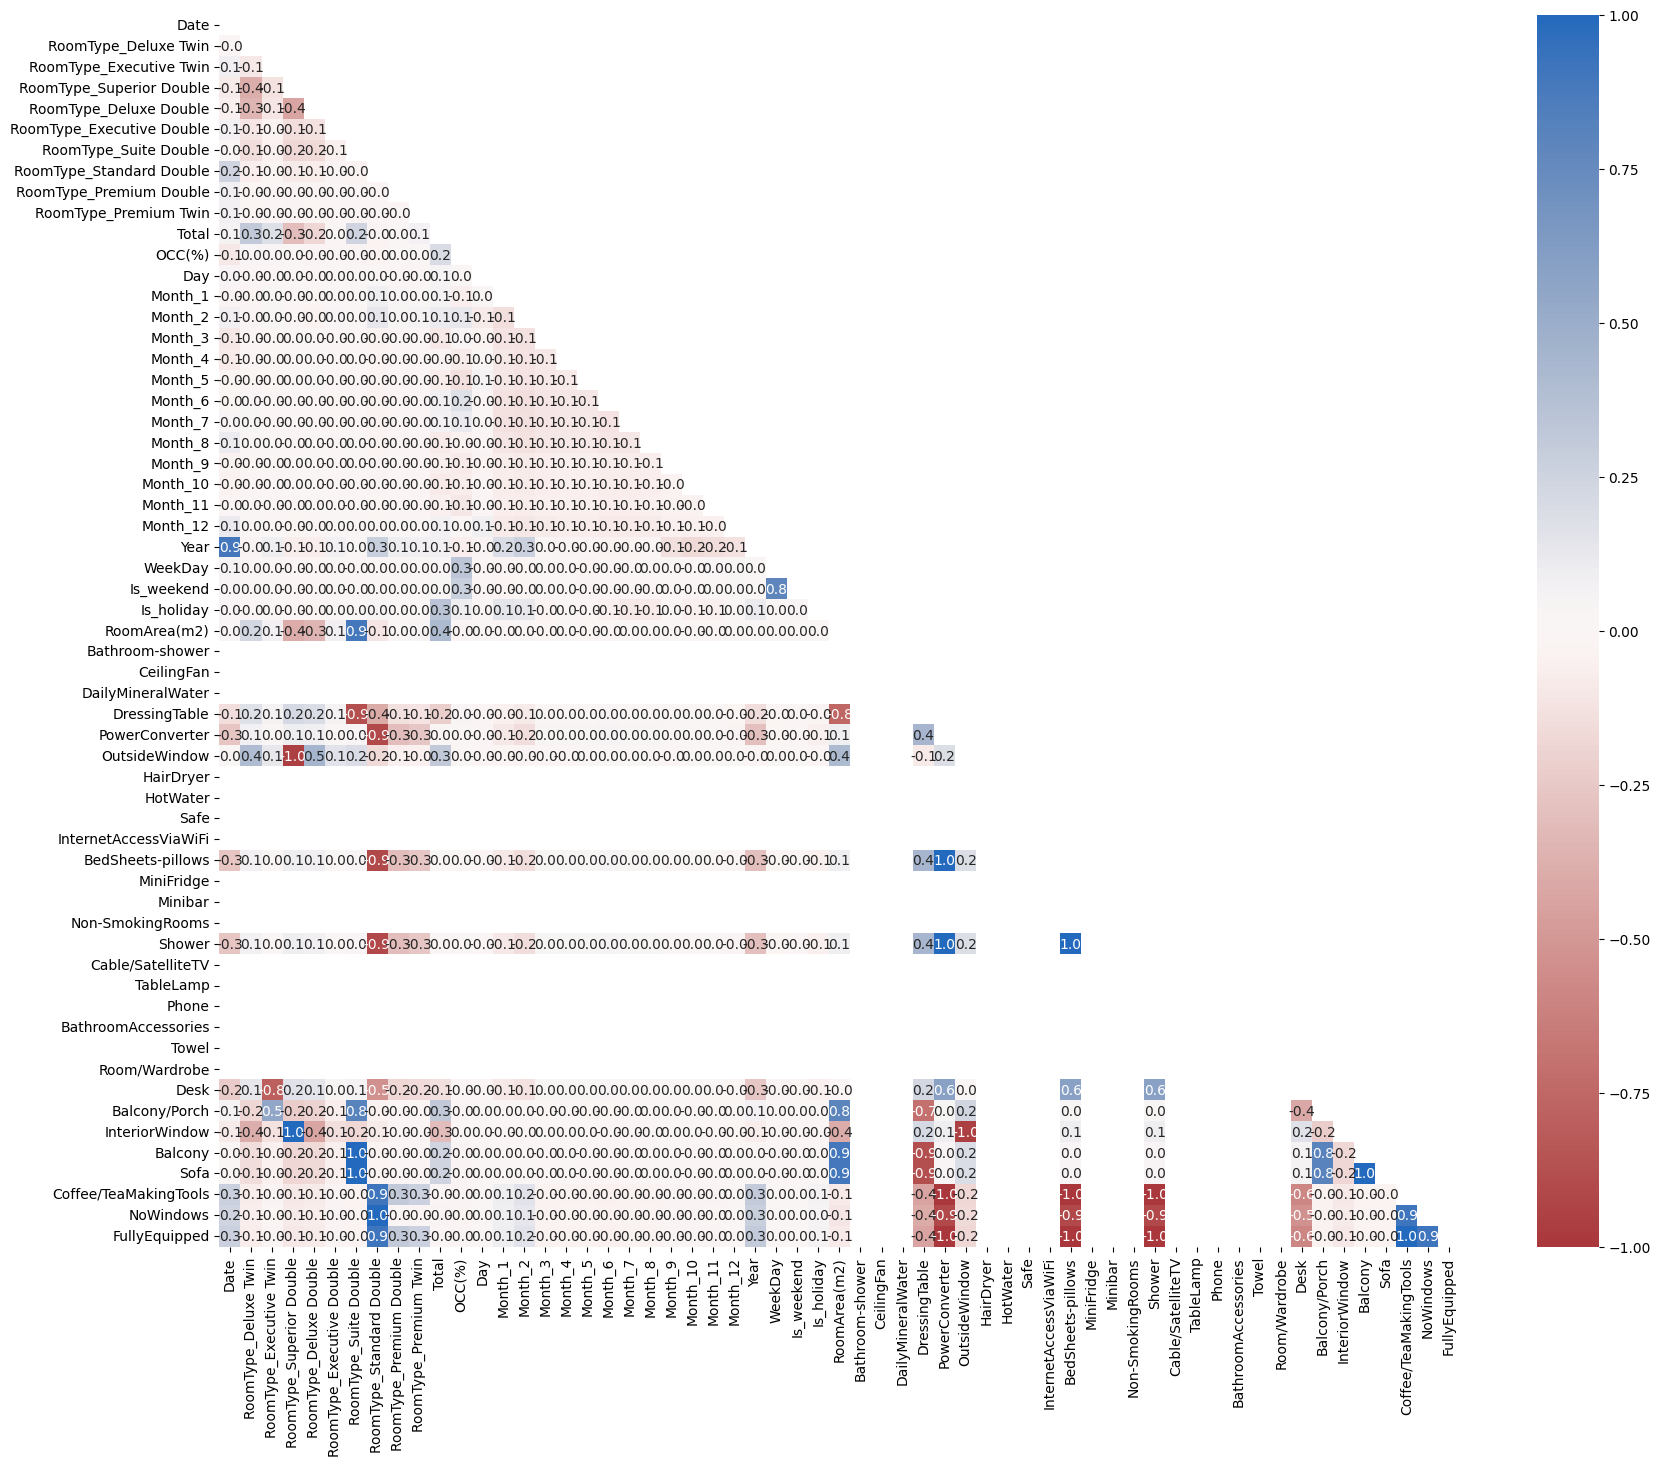

In [ ]:
# Tạo một ma trận boolean với giá trị True trên phần tam giác trên của ma trận tương quan để loại bỏ các giá trị trùng lặp
mask = np.triu(np.ones_like(all_data_corr, dtype=bool))

# Tạo một figure với kích thước 20x16 inch
fig = plt.figure(figsize=(20, 16))

# Vẽ biểu đồ heatmap với ma trận tương quan và các giá trị được chú thích bên trong hình, giữa [-1,1]
# Định dạng các giá trị chú thích với độ chính xác 1 chữ số thập phân
# Chọn màu sắc cho biểu đồ và loại bỏ các giá trị nằm trên phần tam giác dưới của ma trận
sns.heatmap(all_data_corr,annot = True, fmt = '.1f',  cmap = 'vlag_r',mask=mask)

In [ ]:
del list  # Xóa biến 'list' nếu có

from sklearn.feature_selection import SelectKBest, mutual_info_regression

X = df.drop(columns=["Date", "Total"])  # Loại bỏ Date và biến mục tiêu
y = df["Total"]

# Dùng mutual_info_regression cho bài toán hồi quy
selector = SelectKBest(score_func=mutual_info_regression, k=10)
X_new = selector.fit_transform(X, y)

# Lấy các thuộc tính được chọn
selected_features = X.columns[selector.get_support()]

# In ra các thuộc tính được chọn
print("Các thuộc tính được chọn:", list(selected_features))  # Đảm bảo không ghi đè `list`

Các thuộc tính được chọn: ['OCC(%)', 'Day', 'Year', 'RoomArea(m2)', 'OutsideWindow', 'Balcony/Porch', 'InteriorWindow', 'RoomType_Deluxe Double', 'RoomType_Deluxe Twin', 'RoomType_Superior Double']


In [ ]:
# Lọc ra bảng dữ liệu mới với các thuộc tính được chọn
df_selected = df[selected_features]

# In ra bảng dữ liệu mới chỉ chứa các thuộc tính đã chọn
df_selected.head()

,OCC(%),Day,Year,RoomArea(m2),OutsideWindow,Balcony/Porch,InteriorWindow,RoomType_Deluxe Double,RoomType_Deluxe Twin,RoomType_Superior Double
0,73.333333,1,2023,25,1,0,0,0,1,0
1,73.333333,1,2023,25,1,1,0,0,0,0
2,73.333333,1,2023,25,1,0,0,0,1,0
3,73.333333,1,2023,20,0,0,1,0,0,1
4,73.333333,1,2023,25,1,0,0,0,1,0


# 4. Xây dựng mô hình và đánh giá

4.1. Chia dữ liệu thành tập data train/test

In [ ]:
df.head(5)

,Date,Total,OCC(%),Day,Year,WeekDay,Is_weekend,Is_holiday,RoomArea(m2),Bathroom-shower,...,Month_3,Month_4,Month_5,Month_6,Month_7,Month_8,Month_9,Month_10,Month_11,Month_12
6,2023-01-01,1100000.0,73.333333,1,2023,8,1,1,20,1,...,0,0,0,0,0,0,0,0,0,0
13,2023-01-01,764235.0,73.333333,1,2023,8,1,1,20,1,...,0,0,0,0,0,0,0,0,0,0
25,2023-01-02,400000.0,36.666667,2,2023,2,0,0,20,1,...,0,0,0,0,0,0,0,0,0,0
26,2023-01-02,400000.0,36.666667,2,2023,2,0,0,20,1,...,0,0,0,0,0,0,0,0,0,0
33,2023-01-03,528986.0,56.666667,3,2023,3,0,0,20,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Tách dữ liệu thành biến đầu vào (X) và biến mục tiêu (y)
X = df.drop(columns=["Date", "Total"])  # Loại bỏ Date và biến mục tiêu
y = df["Total"]

# Chia dữ liệu thành tập huấn luyện và kiểm tra (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train: {X_train.shape}, \nX_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, \ny_test: {y_test.shape}")

X_train: (10604, 59), 
X_test: (2651, 59)
y_train: (10604,), 
y_test: (2651,)


4.2. Kiểm tra phân phối chuẩn và lựa chọn mô hình phù hợp

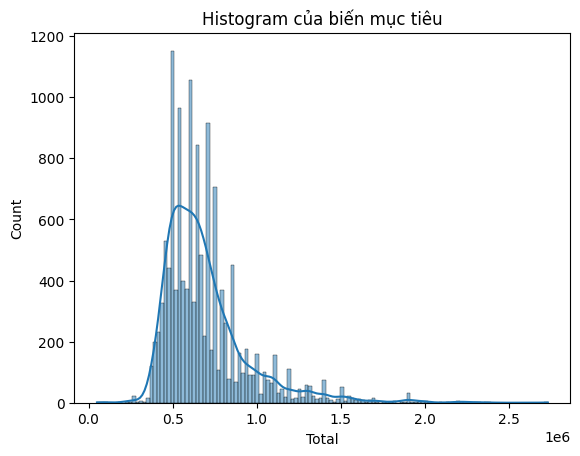

Shapiro-Wilk Test: p-value = 1.354056657988534e-79


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 13255.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
import scipy.stats as stats

sns.histplot(df["Total"], kde=True)
plt.title("Histogram của biến mục tiêu")
plt.show()

# Kiểm tra phân phối chuẩn
stat, p = stats.shapiro(df["Total"])
print(f"Shapiro-Wilk Test: p-value = {p}")

Do dữ liệu không tuân theo phân phối chuẩn, ta chọn một trong số thuật toán không yêu cầu dữ liệu phải tuân theo phân phối chuẩn như:
1.   Random Forest
2.   Gradient Boosting (XGBoost, LightGBM, CatBoost)
3.   SVM (Support Vector Machine)
4.   KNN Regression

4.2. Xây dựng mô hình Catboost

Chạy mô hình với các tham số độ sâu và tốc độ học khác nhau để chọn thông số phù hợp nhất

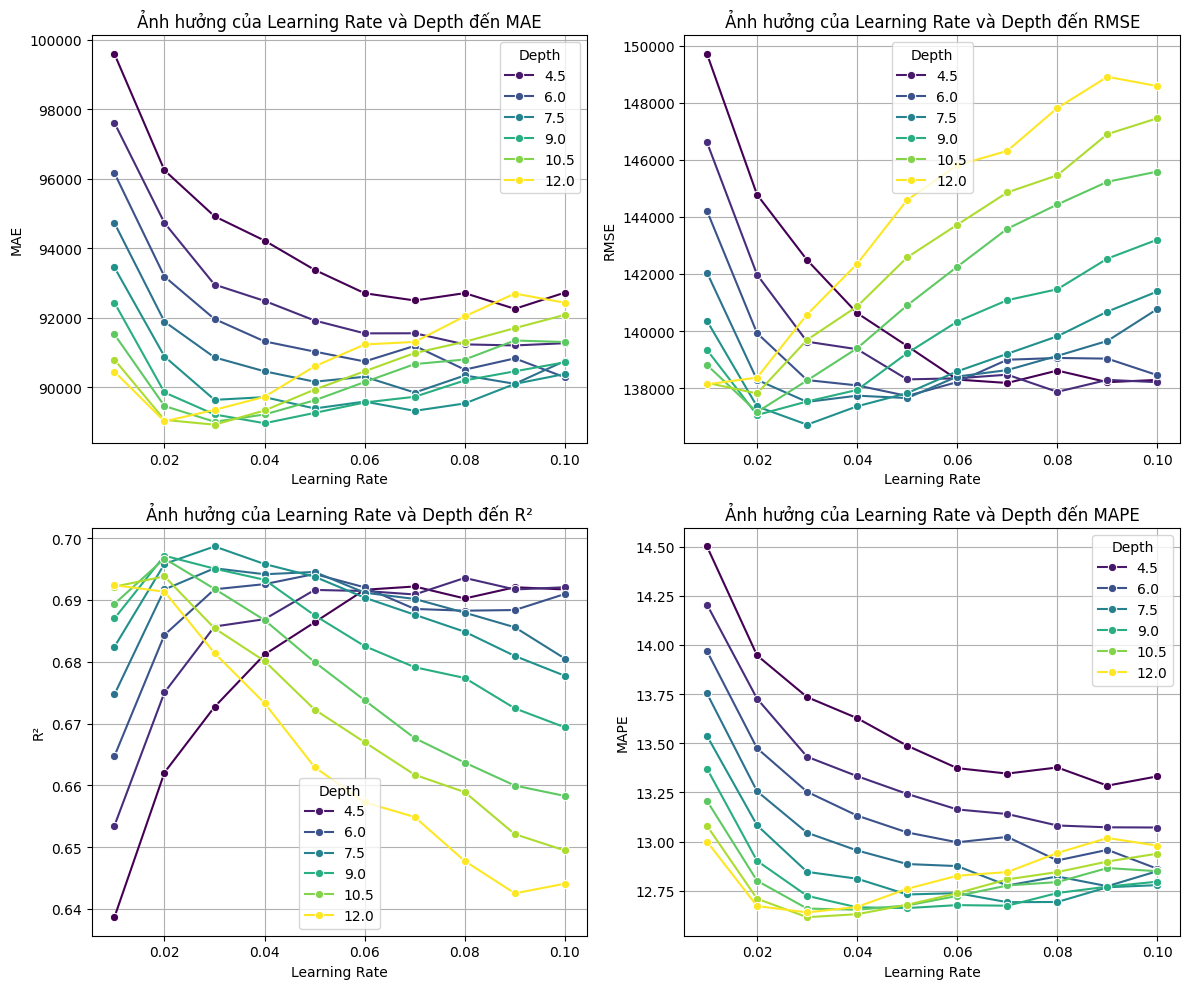

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Lưu kết quả
results = []

# Duyệt qua các giá trị depth và learning_rate
for depth in range(4, 13):  # Từ 4 đến 12
    for lr in np.arange(0.01, 0.11, 0.01):  # Từ 0.01 đến 0.1 với bước nhảy 0.01
        model = CatBoostRegressor(depth=depth, learning_rate=lr, iterations=500, verbose=0)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Tính các chỉ số đánh giá
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE %

        # Lưu vào danh sách
        results.append((depth, lr, mae, rmse, r2, mape))

# Chuyển dữ liệu thành numpy array để dễ xử lý
results = np.array(results)

# Danh sách các chỉ số đánh giá (bỏ MSE)
metrics = ["MAE", "RMSE", "R²", "MAPE"]
metric_indices = [2, 3, 4, 5]  # Vị trí cột tương ứng trong mảng `results`

# Vẽ từng biểu đồ cho từng chỉ số
plt.figure(figsize=(12, 10))

for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i + 1)  # Lưới 2x2
    sns.lineplot(
        x=results[:, 1],  # Learning rate
        y=results[:, metric_indices[i]],  # Giá trị metric
        hue=results[:, 0],  # Depth
        palette="viridis",
        marker="o"
    )
    plt.xlabel("Learning Rate")
    plt.ylabel(metric)
    plt.title(f"Ảnh hưởng của Learning Rate và Depth đến {metric}")
    plt.legend(title="Depth", loc='best')
    plt.grid(True)
    plt.savefig(f"metric_{i+1}_{metric}.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

Liệt kê các thông số độ sâu và tốc độ học tốt nhất tương ứng với từng thông số đánh giá mô hình

In [ ]:
import pandas as pd

# Chuyển dữ liệu thành DataFrame
df_results = pd.DataFrame(results, columns=["Depth", "Learning Rate", "MAE", "RMSE", "R2", "MAPE"])

# Tìm hàng có giá trị tốt nhất cho từng chỉ số
best_mae_row = df_results.loc[df_results["MAE"].idxmin()]    # MAE nhỏ nhất
best_rmse_row = df_results.loc[df_results["RMSE"].idxmin()]  # RMSE nhỏ nhất
best_r2_row = df_results.loc[df_results["R2"].idxmax()]      # R² lớn nhất
best_mape_row = df_results.loc[df_results["MAPE"].idxmin()]  # MAPE nhỏ nhất

# In kết quả
print("🔹 Chỉ số tốt nhất và tham số tương ứng:")
print(f"✅ MAE nhỏ nhất: {best_mae_row['MAE']:.4f} (Depth={best_mae_row['Depth']}, LR={best_mae_row['Learning Rate']})")
print(f"✅ RMSE nhỏ nhất: {best_rmse_row['RMSE']:.4f} (Depth={best_rmse_row['Depth']}, LR={best_rmse_row['Learning Rate']})")
print(f"✅ R² lớn nhất: {best_r2_row['R2']:.4f} (Depth={best_r2_row['Depth']}, LR={best_r2_row['Learning Rate']})")
print(f"✅ MAPE nhỏ nhất: {best_mape_row['MAPE']:.2f}% (Depth={best_mape_row['Depth']}, LR={best_mape_row['Learning Rate']})")

🔹 Chỉ số tốt nhất và tham số tương ứng:
✅ MAE nhỏ nhất: 88915.5081 (Depth=11.0, LR=0.03)
✅ RMSE nhỏ nhất: 136716.9624 (Depth=8.0, LR=0.03)
✅ R² lớn nhất: 0.6987 (Depth=8.0, LR=0.03)
✅ MAPE nhỏ nhất: 12.62% (Depth=11.0, LR=0.03)


In [ ]:
# Khởi tạo mô hình với các tham số cơ bản
model = CatBoostRegressor(
    iterations=1000,  # Số vòng lặp (cây)
    depth=8,         # Độ sâu của cây
    learning_rate=0.03,
    loss_function='RMSE',  # Hàm mất mát cho hồi quy
    verbose=100          # Hiển thị log sau mỗi 100 vòng lặp
)

# Huấn luyện mô hình
model.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50, use_best_model=True)

0:	learn: 255150.7193528	test: 244725.7898509	best: 244725.7898509 (0)	total: 53.8ms	remaining: 53.7s
100:	learn: 146365.6503578	test: 144256.4078066	best: 144256.4078066 (100)	total: 592ms	remaining: 5.26s
200:	learn: 136908.4911846	test: 139238.0188307	best: 139238.0188307 (200)	total: 1.11s	remaining: 4.41s
300:	learn: 131937.1407421	test: 137515.8478625	best: 137513.4876431 (298)	total: 1.64s	remaining: 3.81s
400:	learn: 127881.9153750	test: 136777.8677448	best: 136770.2835949 (399)	total: 2.16s	remaining: 3.23s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 136573.7186
bestIteration = 428

Shrink model to first 429 iterations.


4.3. Tính toán độ quan trọng của các biến

<ipython-input-15-3eac3ba4f099>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_names, palette='viridis')


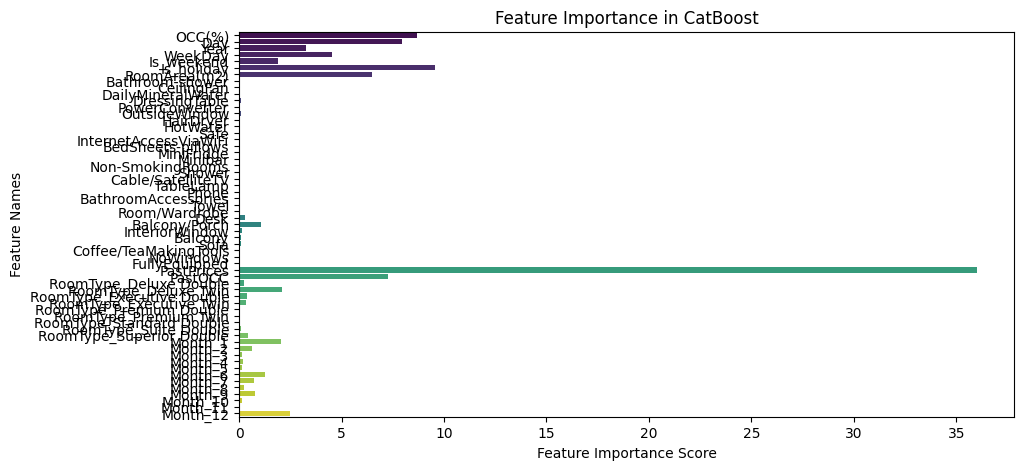

In [ ]:
# Lấy danh sách tên đặc trưng nếu X_train là DataFrame
if isinstance(X_train, pd.DataFrame):
    feature_names = X_train.columns.tolist()
else:
    feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]

# Lấy độ quan trọng của từng đặc trưng từ mô hình đã huấn luyện
feature_importances = model.get_feature_importance()

# Trực quan hóa
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importances, y=feature_names, palette='viridis')
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Names")
plt.title("Feature Importance in CatBoost")
plt.show()

Lưu mô hình

In [ ]:
model.save_model("modelCatBoostHQ.cbm")

4.4. Đánh giá mô hình

Tính toán các chỉ số đánh giá mô hình:
1.   RMSE: Đo lường mức độ chênh lệch trung bình giữa giá trị dự đoán và giá trị thực tế.
2.   MAE: Đo lường trung bình độ lệch tuyệt đối giữa giá trị dự đoán và giá trị thực tế.
3.   R2: Đo lường mức độ mô hình giải thích được phương sai của dữ liệu.
4.   MSE: Giống RMSE, nhưng không lấy căn bậc hai.
5.   MAPE: Đo lường mức độ sai lệch của mô hình dưới dạng phần trăm.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Dự đoán trên tập train
y_train_pred = model.predict(X_train)

# Dự đoán trên tập test
y_test_pred = model.predict(X_test)

# Hàm tính MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100  # Kết quả trả về %

# Đánh giá trên tập train
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)

# Đánh giá trên tập test
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred)

# In kết quả
print("\n🔹 **Kết quả trên tập TRAIN:**")
print(f"RMSE: {rmse_train:.4f}")
print(f"MAE: {mae_train:.4f}")
print(f"R²: {r2_train:.4f}")
print(f"MAPE: {mape_train:.2f}%")

print("\n🔹 **Kết quả trên tập TEST:**")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE: {mae_test:.4f}")
print(f"R²: {r2_test:.4f}")
print(f"MAPE: {mape_test:.2f}%")


🔹 **Kết quả trên tập TRAIN:**
RMSE: 126912.6443
MAE: 84949.1867
R²: 0.7609
MAPE: 12.62%

🔹 **Kết quả trên tập TEST:**
RMSE: 136573.7186
MAE: 89924.9183
R²: 0.6993
MAPE: 12.91%


In [ ]:
def inverse_one_hot(df, prefix_list):
    df_decoded = df.copy()
    for prefix in prefix_list:
        cols = [col for col in df.columns if col.startswith(prefix + "_")]
        df_decoded[prefix] = df[cols].idxmax(axis=1).str.replace(f"{prefix}_", "")
        df_decoded.drop(columns=cols, inplace=True)
    return df_decoded

In [ ]:
prefixes = ["RoomType"]  # Các prefix đã one-hot
df_Xtr = inverse_one_hot(X_train, prefixes)
df_Xt = inverse_one_hot(X_test, prefixes)

In [ ]:
dtr = pd.DataFrame({'RoomType': df_Xtr['RoomType'],'Actual': y_train, 'Predicted': y_train_pred})
dt = pd.DataFrame({'RoomType': df_Xt['RoomType'],'Actual': y_test, 'Predicted': y_test_pred})

Vẽ biểu đồ so sánh giữa giá trị thực và giá trị dự đoán

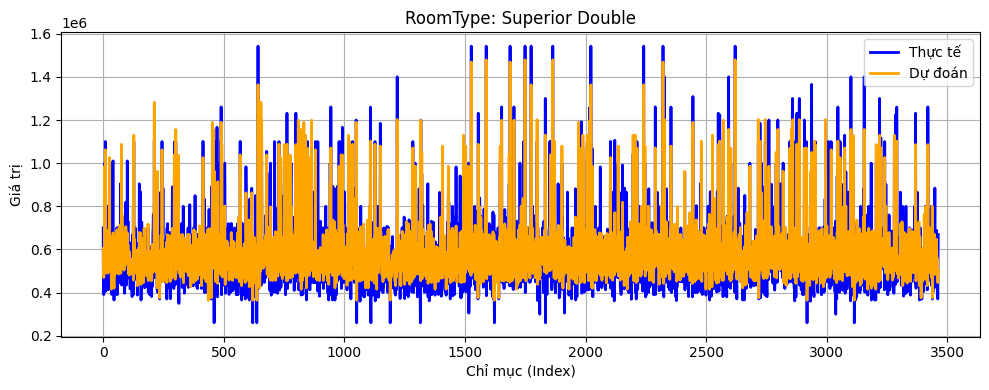

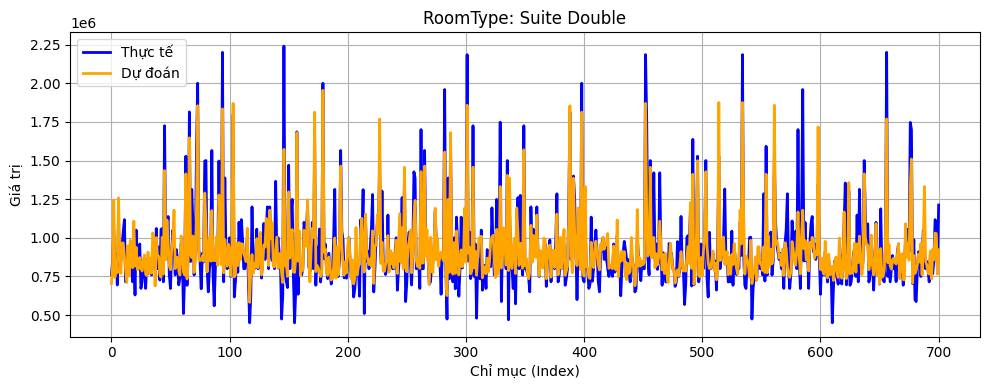

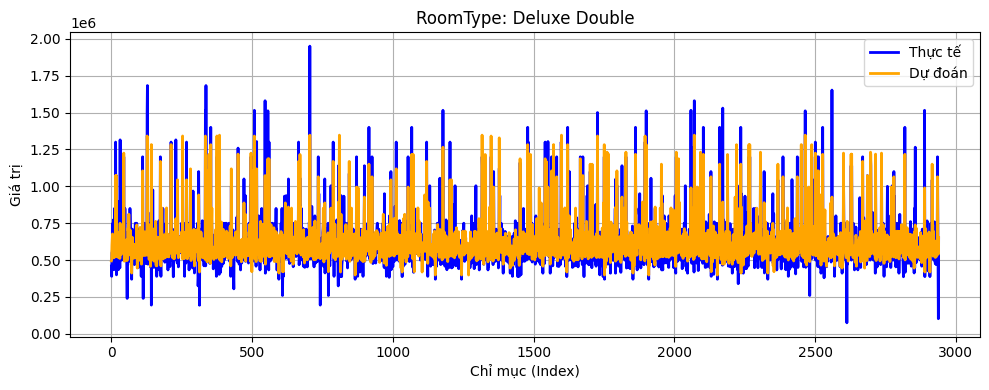

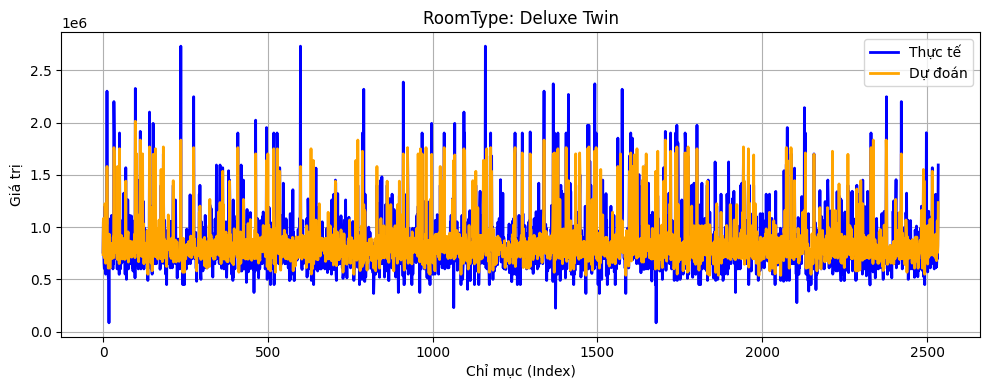

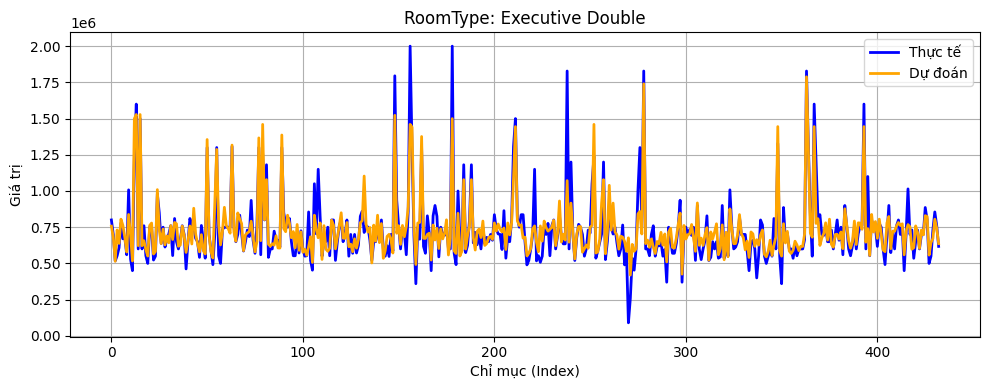

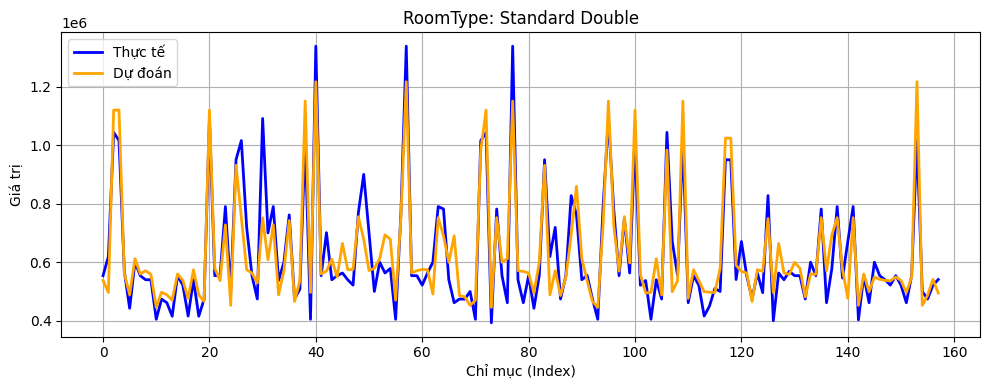

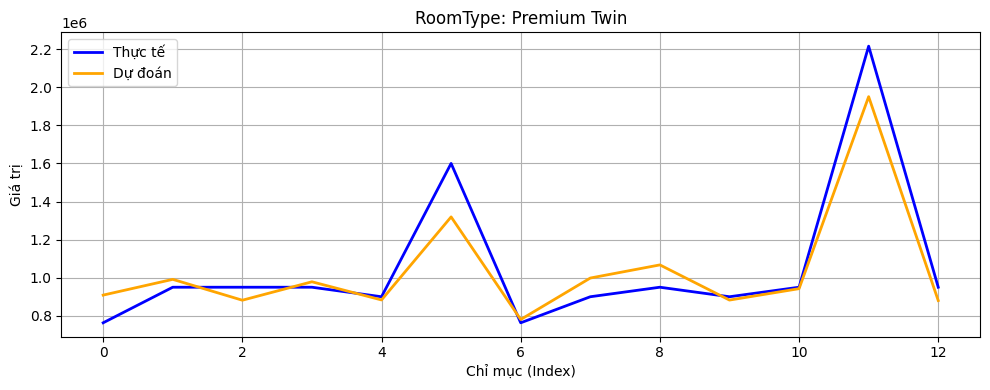

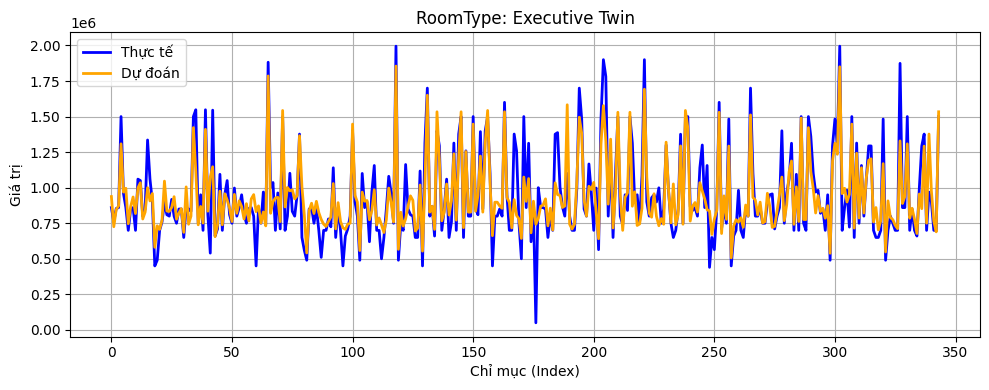

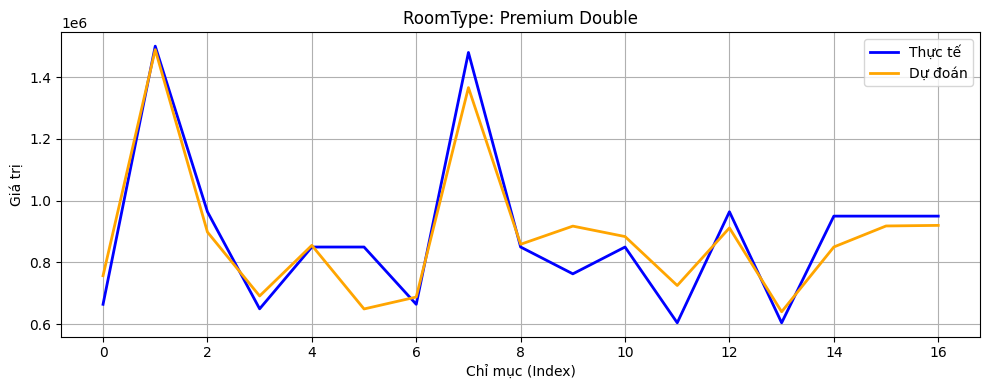

In [ ]:
import matplotlib.pyplot as plt

# Gộp dữ liệu train và test
df_all = dtr

# Lấy danh sách các loại phòng
room_types = df_all['RoomType'].unique()

# Vẽ từng biểu đồ
for room in room_types:
    subset = df_all[df_all['RoomType'] == room].reset_index(drop=True)

    plt.figure(figsize=(10, 4))

    # Vẽ 2 đường thẳng, không có marker
    plt.plot(subset['Actual'], label='Thực tế', color='blue', linewidth=2)
    plt.plot(subset['Predicted'], label='Dự đoán', color='orange', linewidth=2)

    plt.title(f'RoomType: {room}')
    plt.xlabel('Chỉ mục (Index)')
    plt.ylabel('Giá trị')
    plt.legend()  # Hiển thị legend để phân biệt 2 đường
    plt.grid(True)
    plt.tight_layout()
    plt.show()

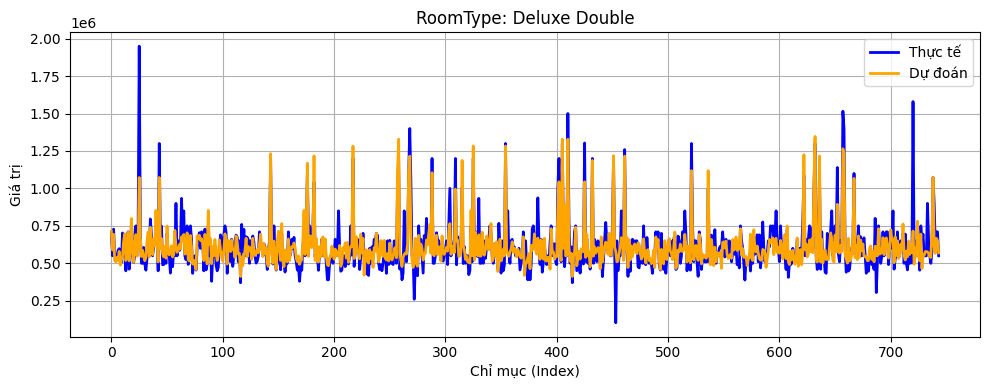

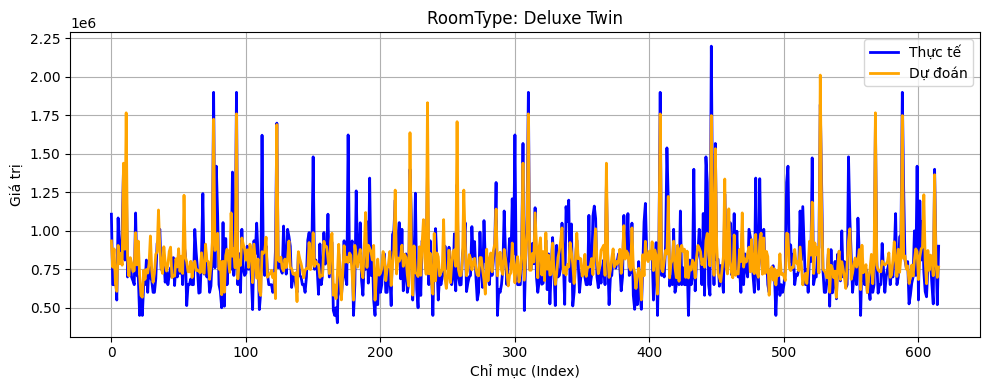

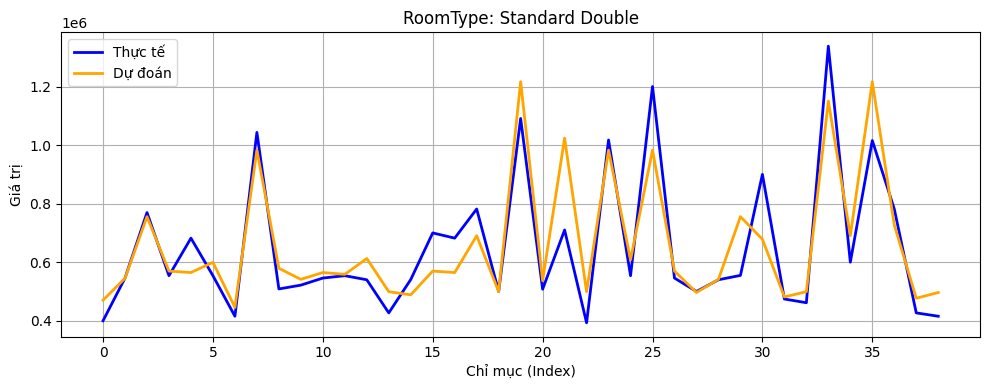

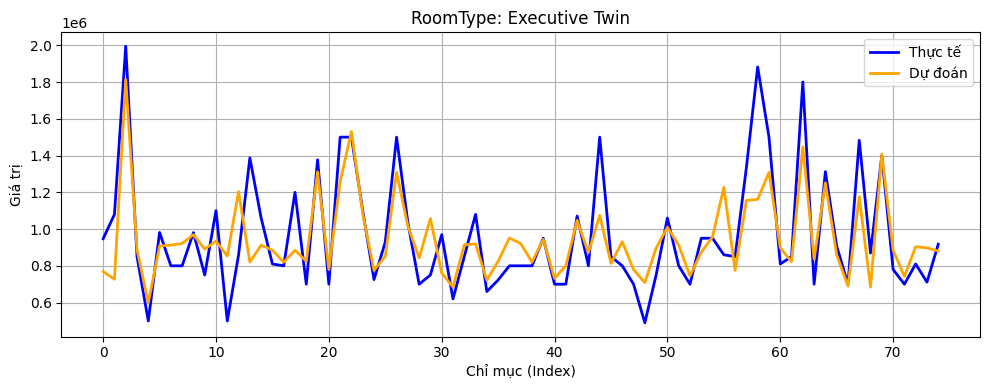

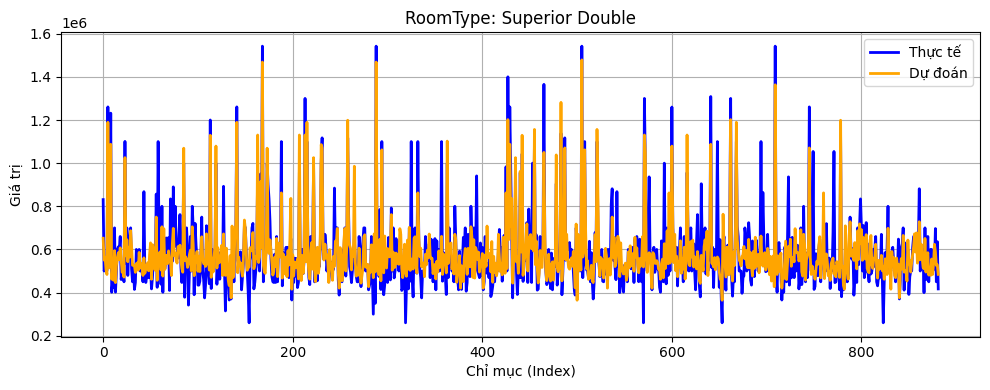

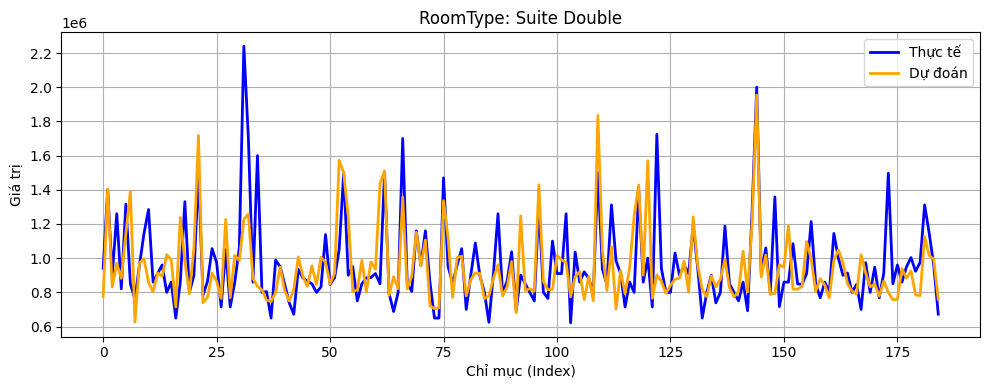

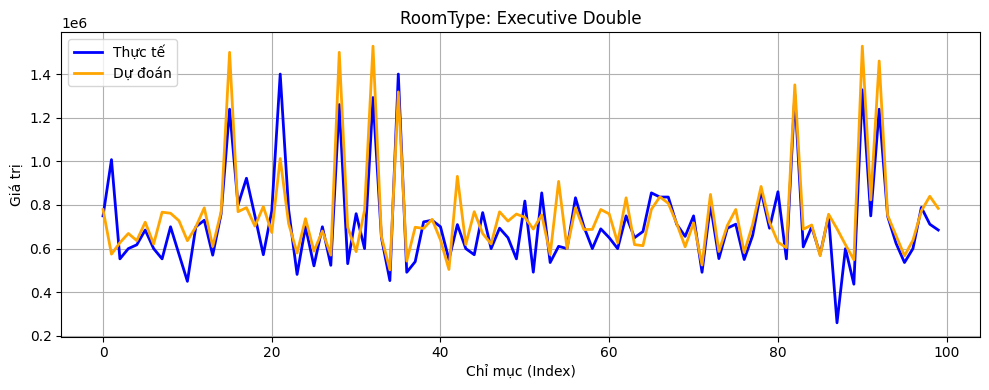

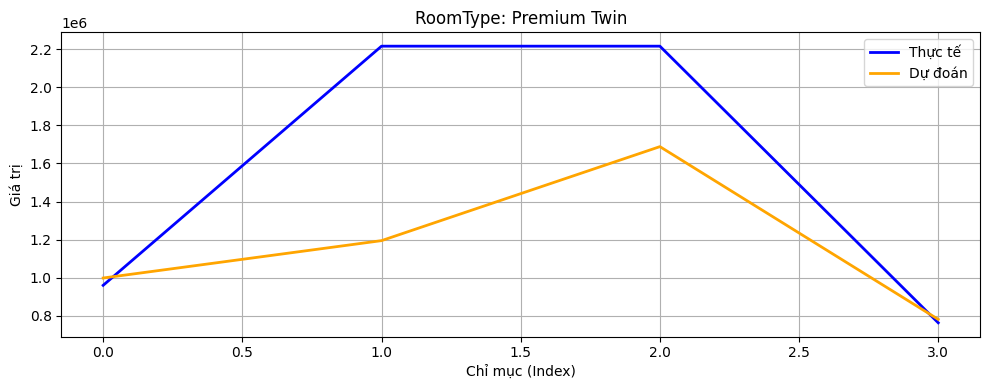

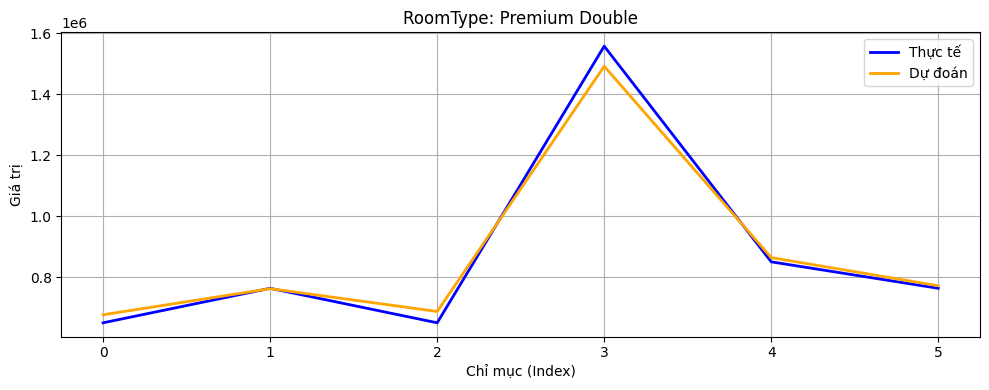

In [ ]:
import matplotlib.pyplot as plt

# Gộp dữ liệu train và test
df_all = dt

# Lấy danh sách các loại phòng
room_types = df_all['RoomType'].unique()

# Vẽ từng biểu đồ
for room in room_types:
    subset = df_all[df_all['RoomType'] == room].reset_index(drop=True)

    plt.figure(figsize=(10, 4))

    # Vẽ 2 đường thẳng, không có marker
    plt.plot(subset['Actual'], label='Thực tế', color='blue', linewidth=2)
    plt.plot(subset['Predicted'], label='Dự đoán', color='orange', linewidth=2)

    plt.title(f'RoomType: {room}')
    plt.xlabel('Chỉ mục (Index)')
    plt.ylabel('Giá trị')
    plt.legend()  # Hiển thị legend để phân biệt 2 đường
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Tính toán so sánh giữa doanh thu thực và doanh thu dự đoán

In [ ]:
# Tính tổng trên tập train
train_actual_sum = y_train.sum()
train_pred_sum = y_train_pred.sum()
train_diff = train_actual_sum - train_pred_sum

# Tính tổng trên tập test
test_actual_sum = y_test.sum()
test_pred_sum = y_test_pred.sum()
test_diff = test_actual_sum - test_pred_sum

# In kết quả
print(f"📌 Train Actual Sum: {train_actual_sum}")
print(f"📌 Train Predicted Sum: {train_pred_sum}")
print(f"🔹 Train Difference: {train_diff}\n")

print(f"📌 Test Actual Sum: {test_actual_sum}")
print(f"📌 Test Predicted Sum: {test_pred_sum}")
print(f"🔹 Test Difference: {test_diff}")

📌 Train Actual Sum: 7374684553.35
📌 Train Predicted Sum: 7374236658.4644
🔹 Train Difference: 447894.88560009

📌 Test Actual Sum: 1831626257.4
📌 Test Predicted Sum: 1832844280.5021856
🔹 Test Difference: -1218023.1021854877


Chạy thử và so sánh với các mô hình dự đoán khác

CatBoost - MAE: 89588.2087, RMSE: 138592.5982, R²: 0.6903, MAPE: 12.73%
Random Forest - MAE: 92860.4340, RMSE: 140375.9668, R²: 0.6823, MAPE: 13.35%
XGBoost - MAE: 92961.1711, RMSE: 148812.0326, R²: 0.6430, MAPE: 13.10%
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 501
[LightGBM] [Info] Number of data points in the train set: 10604, number of used features: 41
[LightGBM] [Info] Start training from score 695462.519179
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

<ipython-input-27-9568583f96f2>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y="Model", data=df_results, palette="viridis")
<ipython-input-27-9568583f96f2>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y="Model", data=df_results, palette="viridis")
<ipython-input-27-9568583f96f2>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metric, y="Model", data=df_results, palette="viridis")
<ipython-input-27-9568583f96f2>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

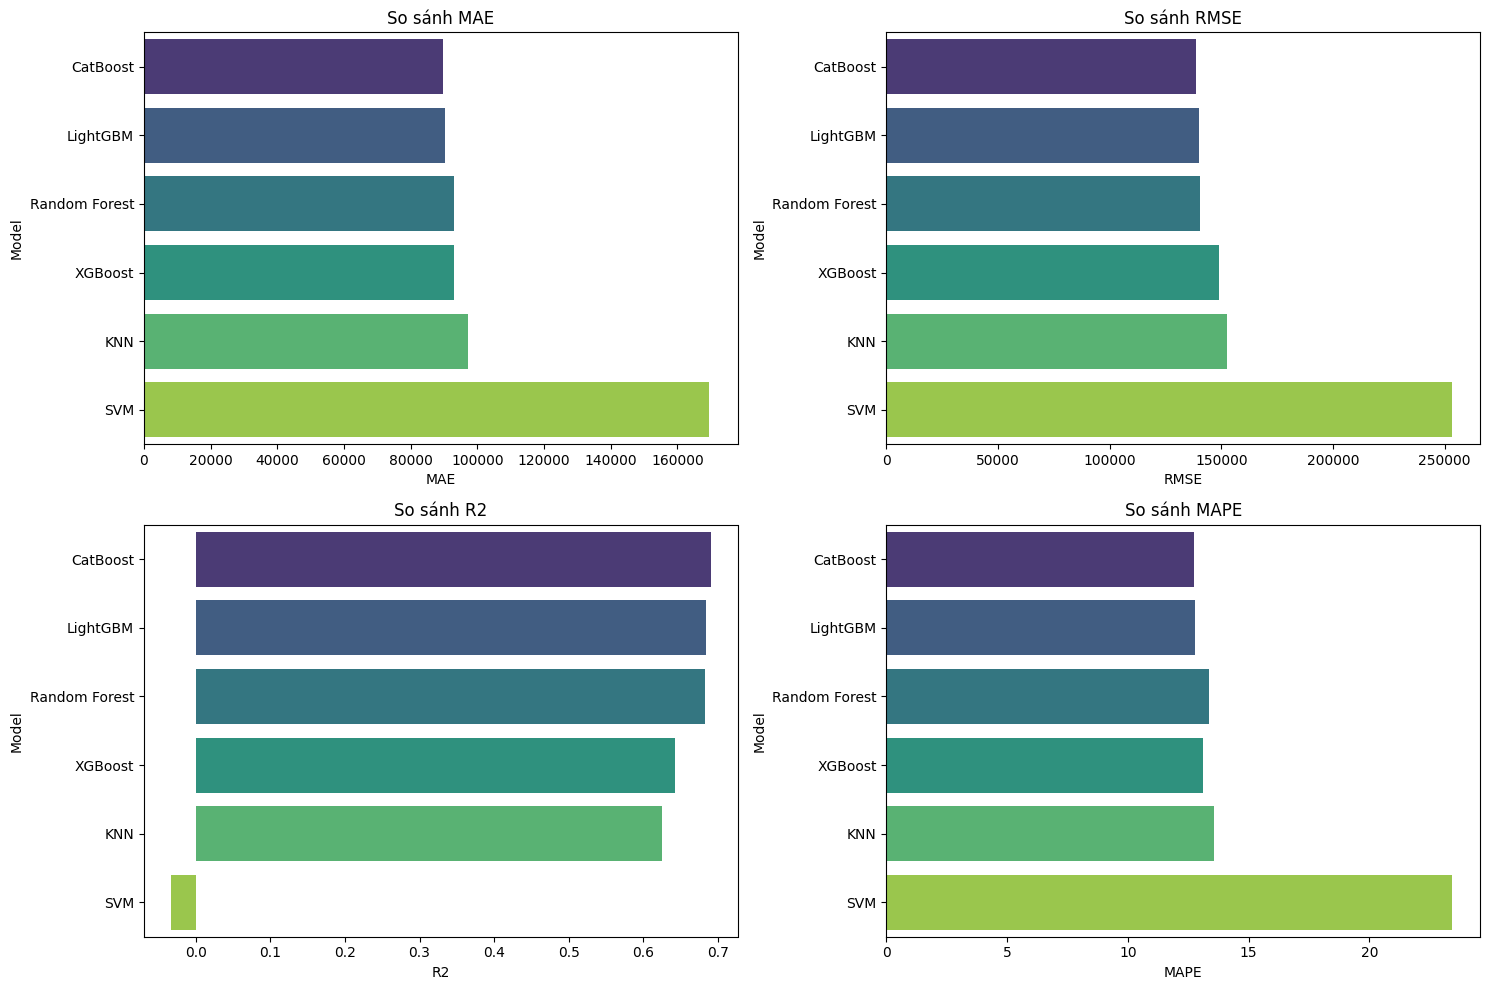

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "CatBoost": CatBoostRegressor(iterations=1000, depth=8, learning_rate=0.03, verbose=0),
    "Random Forest": RandomForestRegressor(n_estimators=1000, max_depth=8),
    "XGBoost": XGBRegressor(n_estimators=1000, max_depth=8, learning_rate=0.03),
    "LightGBM": LGBMRegressor(n_estimators=1000, max_depth=8, learning_rate=0.03),
    "SVM": SVR(kernel='rbf', C=100, gamma=0.1),  # SVM không có tham số max_depth
    "KNN": KNeighborsRegressor(n_neighbors=5)  # KNN không có tham số max_depth hay learning_rate
}


results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Tính toán các chỉ số đánh giá
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # MAPE tính theo %

    results.append((name, mae, rmse, r2, mape))
    print(f'{name} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}, MAPE: {mape:.2f}%')

# Chuyển kết quả thành DataFrame
df_results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2", "MAPE"]).sort_values(by="RMSE")

# Hiển thị bảng kết quả
print("\n🔹 Kết quả so sánh mô hình:")
print(df_results)

# Vẽ biểu đồ cho từng chỉ số đánh giá
metrics = ["MAE", "RMSE", "R2", "MAPE"]
plt.figure(figsize=(15, 10))

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)  # Chia lưới 2x3
    sns.barplot(x=metric, y="Model", data=df_results, palette="viridis")
    plt.title(f"So sánh {metric}")
    plt.xlabel(metric)
    plt.ylabel("Model")

plt.tight_layout()
plt.show()

In [ ]:
df_results.to_csv("Ketqua.csv")

# 5. So sánh với giá phòng của các khách sạn bán kính 1 km và đưa ra giá phòng gợi ý cho khách sạn

5.1 Dự đoán giá phòng

Nhập đầu vào theo thứ tự sau dưới dạng 1 mảng:
[RoomType, OCC, Day, Month, Year, WeekDay, Is_weekend, Is_holiday, RoomArea, Bathroom-shower, CeilingFan, DailyMineralWater, DressingTable, PowerConverter, OutsideWindow, HairDryer, HotWater, Safe, InternetAccessViaWiFi, BedSheets-pillows, MiniFridge, Minibar, Non-SmokingRooms, Shower, Cable/SatelliteTV, TableLamp, Phone, BathroomAccessories, Towel, Room/Wardrobe, Desk, Balcony/Porch, InteriorWindow, Balcony, Sofa, Coffee/TeaMakingTools, NoWindows, FullyEquipped]

Note:

'Deluxe Twin':1, 'Executive Twin':2, 'Superior Double':3, 'Deluxe Double':4,   'Executive Double':5, 'Suite Double':6, 'Standard Double':7, 'Premium Double':8, 'Premium Twin':9

'Monday':2, 'Tuesday':3, 'Wednesday':4, 'Thursday':5, 'Friday':6, 'Saturday':7, 'Sunday':8

In [ ]:
RoomType = 1  #Loại phòng
RoomType_Deluxe_Twin = 0
RoomType_Executive_Twin = 0
RoomType_Superior_Double = 0
RoomType_Deluxe_Double = 0
RoomType_Executive_Double = 0
RoomType_Suite_Double = 0
RoomType_Standard_Double = 0
RoomType_Premium_Double = 0
RoomType_Premium_Twin = 0
if RoomType == 1:
  RoomType_Deluxe_Twin = 1
elif RoomType == 2:
  RoomType_Executive_Twin = 1
elif RoomType == 3:
  RoomType_Superior_Double = 1
elif RoomType == 4:
  RoomType_Deluxe_Double = 1
elif RoomType == 5:
  RoomType_Executive_Double = 1
elif RoomType == 6:
  RoomType_Suite_Double = 1
elif RoomType == 7:
  RoomType_Standard_Double = 1
elif RoomType == 8:
  RoomType_Premium_Double = 1
elif RoomType == 9:
  RoomType_Premium_Twin = 1

In [ ]:
Month = 3
Month_1 = 0
Month_2 = 0
Month_3 = 0
Month_4 = 0
Month_5 = 0
Month_6 = 0
Month_7 = 0
Month_8 = 0
Month_9 = 0
Month_10 = 0
Month_11 = 0
Month_12 = 0
if Month == 1:
  Month_1 = 1
elif Month == 2:
  Month_2 = 1
elif Month == 3:
  Month_3 = 1
elif Month == 4:
  Month_4 = 1
elif Month == 5:
  Month_5 = 1
elif Month == 6:
  Month_6 = 1
elif Month == 7:
  Month_7 = 1
elif Month == 8:
  Month_8 = 1
elif Month == 9:
  Month_9 = 1
elif Month == 10:
  Month_10 = 1
elif Month == 11:
  Month_11 = 1
elif Month == 12:
  Month_12

In [ ]:
OCC = 73.3  #Công suất phòng
Day = 6 #Ngày
Year = 2025 #Năm
WeekDay = 5 #Thứ trong tuần
Is_weekend = 0  #Có phải ngày cuối tuần không?
Is_holiday = 0  #Có phải ngày lễ không?
RoomArea = 25 #Diện tích phòng
Bathroom_shower = 1 #Phòng tắm - vòi sen
CeilingFan = 1  #Quạt trần
DailyMineralWater = 1 #Nước khoáng hằng ngày
DressingTable = 1 #Bàn trang điểm
PowerConverter = 1  #Thiết bị chuyển đổi điện
OutsideWindow = 1 #Cửa sổ bên ngoài
HairDryer = 1 #Máy sấy tóc
HotWater = 1  #Nước nóng
Safe = 1  #Két an toàn
InternetAccessViaWiFi = 1 #Truy cập Internet qua Wifi
BedSheets_pillows = 1 #Ra trải giường, gối
MiniFridge = 1  #Tủ lạnh nhỏ
Minibar = 1 #Quầy bar mini
Non_SmokingRooms = 1 #Phòng không hút thuốc
Shower = 1 #Vòi sen
Cable_SatelliteTV = 1 #Truyền hình cáp / vệ tinh
TableLamp = 1 #Đèn bàn
Phone = 1 #Điện thoại
BathroomAccessories = 1 #Đồ phòng tắm
Towel = 1 #Khăn tắm
Room_Wardrobe = 1 #Phòng / tủ quần áo
Desk = 1  #Bàn làm việc
Balcony_Porch = 0 #Ban công / hiên
InteriorWindow = 0 #Cửa sổ bên trong
Balcony = 0 #Ban công
Sofa = 0 #Ghế Sofa
Coffee_TeaMakingTools = 0 #Dụng cụ pha cà phê, trà
NoWindows = 0 #Không có cửa sổ
FullyEquipped = 0 #Đầy đủ thiết bị
PastPrices = 0
PastOCC = 50
Test = np.array([OCC, Day, Year, WeekDay, Is_weekend, Is_holiday, RoomArea, Bathroom_shower, CeilingFan, DailyMineralWater, DressingTable, PowerConverter, OutsideWindow, HairDryer, HotWater, Safe, InternetAccessViaWiFi, BedSheets_pillows, MiniFridge, Minibar, Non_SmokingRooms, Shower, Cable_SatelliteTV, TableLamp, Phone, BathroomAccessories, Towel, Room_Wardrobe, Desk, Balcony_Porch, InteriorWindow, Balcony, Sofa, Coffee_TeaMakingTools, NoWindows, FullyEquipped, PastPrices, PastOCC, RoomType_Deluxe_Twin, RoomType_Executive_Twin, RoomType_Superior_Double, RoomType_Deluxe_Double, RoomType_Executive_Double, RoomType_Suite_Double, RoomType_Standard_Double, RoomType_Premium_Double, RoomType_Premium_Twin, Month_1, Month_2, Month_3, Month_4, Month_5, Month_6, Month_7, Month_8, Month_9, Month_10, Month_11, Month_12]).reshape(1, -1)
TienichT = [RoomArea, Bathroom_shower, CeilingFan, DailyMineralWater, DressingTable, PowerConverter, OutsideWindow, HairDryer, HotWater, Safe, InternetAccessViaWiFi, BedSheets_pillows, MiniFridge, Minibar, Non_SmokingRooms, Shower, Cable_SatelliteTV, TableLamp, Phone, BathroomAccessories, Towel, Room_Wardrobe, Desk, Balcony_Porch, InteriorWindow, Balcony, Sofa, Coffee_TeaMakingTools, NoWindows, FullyEquipped]

Tải lại mô hình

In [ ]:
# Khởi tạo đối tượng mô hình hồi quy
loaded_model = CatBoostRegressor()

# Tải mô hình đã lưu
loaded_model.load_model("modelCatBoost.onnx", format='onnx')

Dự đoán giá mới

In [ ]:
predictions = loaded_model.predict(Test)
print(predictions)

[573841.70403835]


5.2 Đọc dữ liệu thông tin phòng tương tự của các khách sạn trong bán kính 1 km

In [ ]:
data_ss = pd.read_excel("/content/drive/My Drive/Data/BookingData_20250306-8h.xlsx", sheet_name="Hotels", engine="openpyxl")
data_ss.head()

,HotelName,RoomType,Price,BedType,RoomSize,Free Wifi,Attached bathroom,Flat-screen TV,Minibar,Balcony,...,Inner courtyard view,Terrace,Lake view,Private kitchen,Barbecue,Entire villa,Private kitchenette,Coffee machine,Sauna,Entire vacation home
0,Tulip City View,Superior Double Room,"VND 545,243",1 queen bed,NaN,Yes,No,No,No,No,...,No,No,No,No,No,No,No,No,No,No
1,Tulip City View,Superior Double Room,"VND 708,773",1 queen bed,NaN,Yes,No,No,No,No,...,No,No,No,No,No,No,No,No,No,No
2,Tulip City View,Deluxe Double Room,"VND 712,942",1 queen bed,20 m²,Yes,Yes,Yes,Yes,No,...,No,No,No,No,No,No,No,No,No,No
3,Tulip City View,Executive Double Room,"VND 787,988",1 queen bed,18 m²,Yes,Yes,Yes,Yes,Yes,...,No,No,No,No,No,No,No,No,No,No
4,Tulip City View,Premium Double Room,"VND 863,035",1 queen bed,35 m²,Yes,Yes,Yes,Yes,No,...,No,No,No,No,No,No,No,No,No,No


5.3 Lọc thông tin giá phòng tương ứng với Loại phòng cần quyết định giá

Tiền xử lý dữ liệu đưa về dạng chuẩn của dữ liệu huấn luyện

In [ ]:
# Kiểm tra và chuyển đổi cột "Price" thành chuỗi trước khi xử lý
if 'Price' in data_ss.columns:
    data_ss['Price'] = data_ss['Price'].astype(str).str.replace(r'[^\d]', '', regex=True).astype(float)

# Xóa các dòng có giá trị rỗng hoặc NaN trong cột "RoomSize"
if 'RoomSize' in data_ss.columns:
    data_ss = data_ss.dropna(subset=['RoomSize'])
# Kiểm tra và chuyển đổi cột "RoomSize" thành chuỗi trước khi xử lý
if 'RoomSize' in data_ss.columns:
    data_ss['RoomSize'] = data_ss['RoomSize'].astype(str).str.replace(r'[^\d]', '', regex=True).astype(float)

# Xóa cột "BedType"
if 'BedType' in data_ss.columns:
    data_ss.drop(columns=['BedType'], inplace=True)

# Xử lý các cột có giá trị "Yes"/"No" thành 1/0
yes_no_columns = data_ss.select_dtypes(include=['object']).columns
for col in yes_no_columns:
    if data_ss[col].dropna().isin(['Yes', 'No']).all():
        data_ss[col] = data_ss[col].map({'Yes': 1, 'No': 0})

# Lưu kết quả vào file mới
#output_path = "Processed_BookingData.xlsx"
#data_ss.to_excel(output_path, index=False)

#output_path

<ipython-input-34-cae902e13365>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ss['RoomSize'] = data_ss['RoomSize'].astype(str).str.replace(r'[^\d]', '', regex=True).astype(float)
<ipython-input-34-cae902e13365>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_ss.drop(columns=['BedType'], inplace=True)
<ipython-input-34-cae902e13365>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pa

Ánh xạ các loại phòng quét được đưa về loại phòng chuẩn chung

In [ ]:
# Tạo ánh xạ từ Room sang RoomType dựa trên bảng hình ảnh
room_mapping = {
    "Deluxe Twin Room": "Deluxe Twin",
    "Deluxe Double or Twin Room": "Deluxe Twin",
    "Deluxe Double or Twin Room with City View": "Deluxe Twin",
    "Executive Twin": "Executive Twin",
    "Superior Double Room": "Superior Double",
    "Superior Double or Twin Room": "Superior Double",
    "Deluxe Double Room": "Deluxe Double",
    "Deluxe Double Room with Balcony": "Deluxe Double",
    "Deluxe Double Room with Bath": "Deluxe Double",
    "Deluxe Double Room with Two Double Beds": "Deluxe Double",
    "Executive Double Room": "Executive Double",
    "Suite": "Suite Double",
    "Suite with City View": "Suite Double",
    "Deluxe Suite": "Suite Double",
    "Family Suite with Balcony": "Suite Double",
    "Family Junior Suite": "Suite Double",
    "Standard Double Room": "Standard Double",
    "Classic Double Room": "Standard Double",
    "Premium Double Room": "Premium Double",
    "Premium Twin": "Premium Twin"
}

# Thêm cột RoomType vào dữ liệu
data_ss["RoomType"] = data_ss["RoomType"].map(room_mapping)

In [ ]:
data_ss

,HotelName,RoomType,Price,RoomSize,Free Wifi,Attached bathroom,Flat-screen TV,Minibar,Balcony,Mountain view,...,Inner courtyard view,Terrace,Lake view,Private kitchen,Barbecue,Entire villa,Private kitchenette,Coffee machine,Sauna,Entire vacation home
2,Tulip City View,Deluxe Double,712942.0,20.0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Tulip City View,Executive Double,787988.0,18.0,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,Tulip City View,Premium Double,863035.0,35.0,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
5,Tulip City View,NaN,1459238.0,35.0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
6,Tulip City View,NaN,1709393.0,35.0,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,Dalat Boutique Hotel,NaN,699300.0,24.0,1,0,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0
350,Golden Bee Hotel,Deluxe Double,513975.0,25.0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
351,Golden Bee Hotel,NaN,562925.0,26.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
352,Golden Bee Hotel,NaN,881100.0,26.0,1,1,1,1,0,0,...,1,0,0,0,0,0,0,0,0,0


Lọc dữ liệu theo loại cần gợi ý giá

In [ ]:
RoomType_Deluxe_Twin, RoomType_Executive_Twin, RoomType_Superior_Double, RoomType_Deluxe_Double, RoomType_Executive_Double, RoomType_Suite_Double, RoomType_Standard_Double, RoomType_Premium_Double, RoomType_Premium_Twin
# Chọn loại phòng cần lọc (thay "Deluxe Twin" bằng tên phòng bạn muốn)
if RoomType_Deluxe_Twin == 1:   room_type_to_filter = "Deluxe Twin"
elif RoomType_Executive_Twin == 1:   room_type_to_filter = "Executive Twin"
elif RoomType_Superior_Double == 1:   room_type_to_filter = "Superior Double"
elif RoomType_Deluxe_Double == 1:   room_type_to_filter = "Deluxe Double"
elif RoomType_Executive_Double == 1:   room_type_to_filter = "Executive Double"
elif RoomType_Suite_Double == 1:   room_type_to_filter = "Suite Double"
elif RoomType_Standard_Double == 1:   room_type_to_filter = "Standard Double"
elif RoomType_Premium_Double == 1:   room_type_to_filter = "Premium Double"
elif RoomType_Premium_Twin == 1:   room_type_to_filter = "Premium Twin"

# Lọc dữ liệu theo loại phòng
filtered_data = data_ss[data_ss["RoomType"] == room_type_to_filter]
filtered_data

,HotelName,RoomType,Price,RoomSize,Free Wifi,Attached bathroom,Flat-screen TV,Minibar,Balcony,Mountain view,...,Inner courtyard view,Terrace,Lake view,Private kitchen,Barbecue,Entire villa,Private kitchenette,Coffee machine,Sauna,Entire vacation home
21,Thanh Thanh 3,Deluxe Twin,611500.0,30.0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
43,Hotel Du Lys,Deluxe Twin,958500.0,32.0,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
69,Nature Hotel - Nam Kỳ Khởi Nghĩa,Deluxe Twin,546000.0,22.0,1,1,1,1,0,0,...,1,0,0,0,0,0,0,0,0,0
88,SANDALS FLORA HOTEL,Deluxe Twin,1256076.0,20.0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
90,SANDALS FLORA HOTEL,Deluxe Twin,1578582.0,25.0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
101,Nice Dream Hotel,Deluxe Twin,1197000.0,40.0,1,1,1,1,1,0,...,1,1,0,0,0,0,0,0,0,0
189,Rum Vang Hotel Da Lat,Deluxe Twin,900000.0,36.0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
193,BIDV Central Da Lat Hotel,Deluxe Twin,442320.0,23.0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
206,Dragon King 1 Hotel,Deluxe Twin,608095.0,20.0,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
221,Mai Thang Hotel Da Lat,Deluxe Twin,765000.0,30.0,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


Ánh xạ các tiện nghi của các khách sạn quét được về chuẩn chung

In [ ]:
df = filtered_data

# Định nghĩa ánh xạ các thuộc tính vào nhóm mới
mapping = {
    "RoomArea(m2)": ["RoomSize"],  # Giữ nguyên giá trị số
    "Bathroom-shower": ["Attached bathroom", "Private bathroom", "Spa tub", "Bathtub", "Sauna"],
    "CeilingFan": [],
    "DailyMineralWater": [],
    "DressingTable": [],
    "PowerConverter": [],
    "OutsideWindow": ["Mountain view", "City view", "Garden view", "Landmark view", "Inner courtyard view", "Lake view"],
    "HairDryer": [],
    "HotWater": [],
    "Safe": [],
    "InternetAccessViaWiFi": ["Free Wifi"],
    "BedSheets-pillows": [],
    "MiniFridge": [],
    "Minibar": ["Minibar"],
    "Non-SmokingRooms": [],
    "Shower": [],
    "Cable/SatelliteTV": ["Flat-screen TV"],
    "TableLamp": [],
    "Phone": [],
    "BathroomAccessories": [],
    "Towel": [],
    "Room/Wardrobe": [],
    "Desk": [],
    "Balcony/Porch": ["Balcony", "Patio", "Terrace"],
    "InteriorWindow": [],
    "Balcony": ["Balcony"],
    "Sofa": [],
    "Coffee/TeaMakingTools": ["Coffee machine"],
    "NoWindows": [],
    "FullyEquipped": ["Private kitchen", "Private kitchenette", "Barbecue", "Entire apartment", "Private suite", "Entire studio", "Entire villa", "Entire vacation home"],
}

# Tạo DataFrame mới với các nhóm, mặc định là 0
df_new = pd.DataFrame(0, index=df.index, columns=mapping.keys())

# Xử lý ánh xạ
for new_col, old_cols in mapping.items():
    if old_cols:
        if new_col == "RoomArea(m2)":  # Giữ nguyên số mét vuông
            df_new[new_col] = df[old_cols[0]]
        else:  # Các cột khác ánh xạ thành 0 hoặc 1
            df_new[new_col] = df[old_cols].apply(lambda row: 1 if (row == "Yes").any() or (row == 1).any() else 0, axis=1)
df_new["Price"] = df["Price"]
# Xuất dữ liệu đã chuyển đổi
#df_new.to_csv("output.csv", index=False)
#print("Chuyển đổi dữ liệu hoàn tất! File output.csv đã được tạo.")

Tách thành 2 bảng dữ liệu: Tiện ích và giá để tiện so sánh các tiện ích với nhau

In [ ]:
Tienich = df_new.drop(columns=["Price"])
Gia = df_new["Price"]

Hàm tính động tương đồng về các tiện nghi theo khoảng cách EUC

In [ ]:
def euclidean_distance(row1, row2):
    row1, row2 = np.array(row1), np.array(row2)
    return np.linalg.norm(row1 - row2)

Tính toán hệ số tường đồng với dữ liệu đã lọc được

In [ ]:
sskc = []
for i in range(Tienich.shape[0]):
    distance = euclidean_distance(TienichT, Tienich.iloc[i].to_numpy())
    sskc.append(distance)

5.4 Đưa ra các gợi ý giá theo các tiêu chí khác nhau (max, min, trung bình)

Chọn k giá phòng có các tiện ích giống với phòng cần gợi ý nhất

In [ ]:
# Số lượng phần tử nhỏ nhất cần lấy
k = 5
Gia = np.array(Gia)
# Lấy index của k giá trị nhỏ nhất
smallest_indices = np.argsort(sskc)[:k]
smallest_values = Gia[smallest_indices]
#print(smallest_indices)
print(smallest_values)
smallest_values = np.append(smallest_values,predictions)
print(smallest_values)
print("Giá dự đoán:", predictions[0])
print("Giá gợi ý nhỏ nhất:", np.min(smallest_values))
print("Giá gợi ý trung bình:", np.mean(smallest_values))
print("Giá gợi ý lớn nhất:", np.max(smallest_values))

[1578582.  703000.  800000.  442320.  546000.]
[1578582.          703000.          800000.          442320.
  546000.          586691.96494268]
Giá dự đoán: 586691.9649426783
Giá gợi ý nhỏ nhất: 442320.0
Giá gợi ý trung bình: 776098.9941571131
Giá gợi ý lớn nhất: 1578582.0


In [ ]:
df_filtered = filtered_data.iloc[smallest_indices, [0, 1, 2]]
df_filtered

,HotelName,RoomType,Price
90,SANDALS FLORA HOTEL,Deluxe Twin,1578582.0
225,President Hotel,Deluxe Twin,703000.0
263,Le Petit Paris Dalat Hotel,Deluxe Twin,800000.0
193,BIDV Central Da Lat Hotel,Deluxe Twin,442320.0
69,Nature Hotel - Nam Kỳ Khởi Nghĩa,Deluxe Twin,546000.0


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_price_comparison(predicted_price, hotels):
    # Đảm bảo hotels là DataFrame
    df = pd.DataFrame(hotels, columns=["HotelName", "Price"])
    df["Pred_Price"] = predicted_price  # Thêm cột giá dự báo

    names = df["HotelName"].tolist()
    actual_prices = df["Price"].tolist()
    predicted_prices = df["Pred_Price"].tolist()

    x = np.arange(len(names))  # Vị trí trên trục x
    width = 0.4  # Độ rộng của cột

    fig, ax = plt.subplots(figsize=(15, 6))

    # Vẽ biểu đồ
    ax.bar(x - width/2, predicted_prices, width, label='Giá dự báo', color='green')
    ax.bar(x + width/2, actual_prices, width, label='Giá thực tế', color='orange')

    # Hiển thị số trên đầu mỗi cột
    for i, bar in enumerate(ax.patches[:len(names)]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(bar.get_height()):,}',
                ha='center', va='bottom', fontsize=10)

    for i, bar in enumerate(ax.patches[len(names):]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(bar.get_height()):,}',
                ha='center', va='bottom', fontsize=10)

    ax.set_xlabel('Khách sạn')
    ax.set_ylabel('Giá (VNĐ)')
    ax.set_title('So sánh giá dự báo và giá thực tế của các khách sạn')
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=0, ha='center')  # Xoay ngang tên khách sạn
    ax.legend()

    plt.tight_layout()
    plt.show()

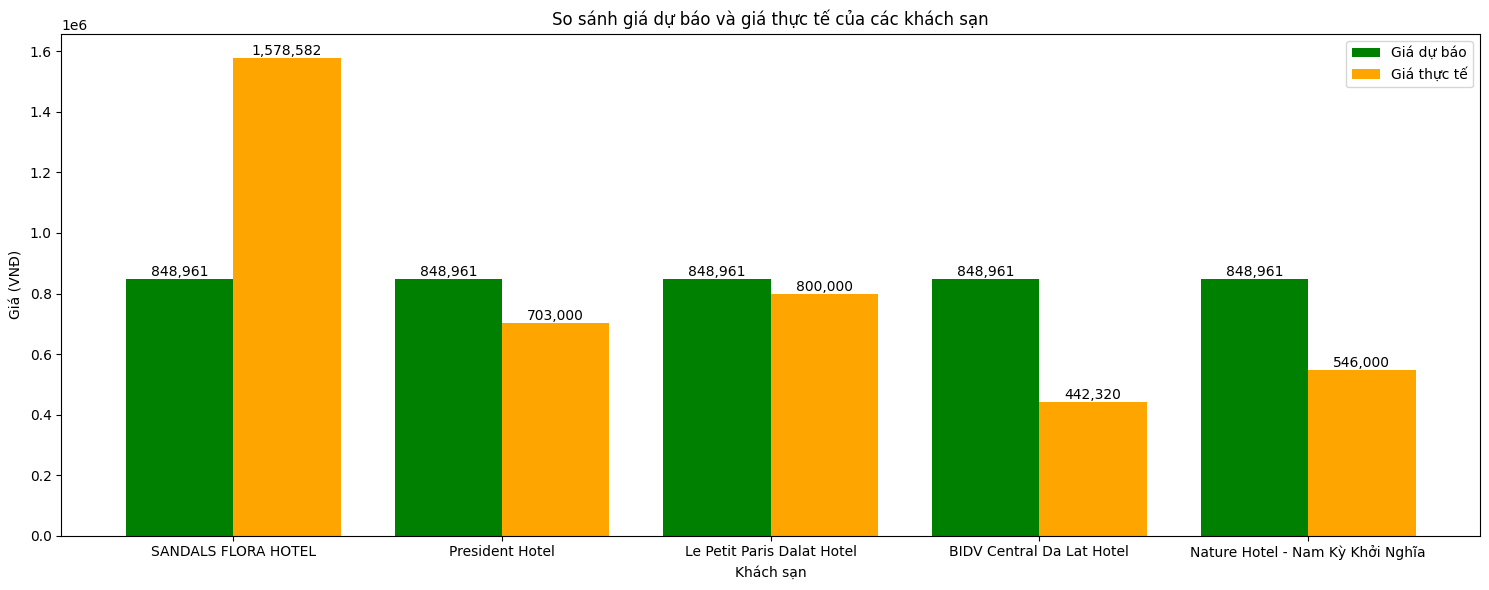

In [ ]:
plot_price_comparison(predictions[0], df_filtered[['HotelName', 'Price']])

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_hotel_price(df):
    """
    Vẽ biểu đồ giá khách sạn từ DataFrame chứa tên khách sạn và giá.

    Tham số:
    df (DataFrame): DataFrame có hai cột: 'HotelName' và 'Price'.
    """
    # Kiểm tra tên cột và loại bỏ khoảng trắng trong tên cột
    df.columns = df.columns.str.strip()

    # Chuyển 'HotelName' về dạng chuỗi
    df['HotelName'] = df['HotelName'].astype(str)

    # Reset index nếu cần
    df = df.reset_index(drop=True)

    # Vẽ biểu đồ
    plt.figure(figsize=(15, 5))
    plt.plot(df['HotelName'], df['Price'], marker='o', linestyle='-', color='b', label='Giá khách sạn')

    # Sửa lỗi hiển thị số mũ trên trục Y
    plt.ticklabel_format(style='plain', axis='y')

    # Hiển thị giá trị chính xác trên từng điểm
    for i, txt in enumerate(df['Price']):
        plt.text(i, df['Price'].iloc[i] + 20000, f"{txt}", ha='center', fontsize=10, color='black')

    # Thêm tiêu đề và nhãn
    plt.title('Giá khách sạn')
    plt.xlabel('Tên khách sạn')
    plt.ylabel('Giá')
    plt.xticks(range(len(df['HotelName'])), df['HotelName'], rotation=0)  # Fix lỗi trục X
    plt.legend()
    plt.grid(True)

    # Hiển thị biểu đồ
    plt.show()

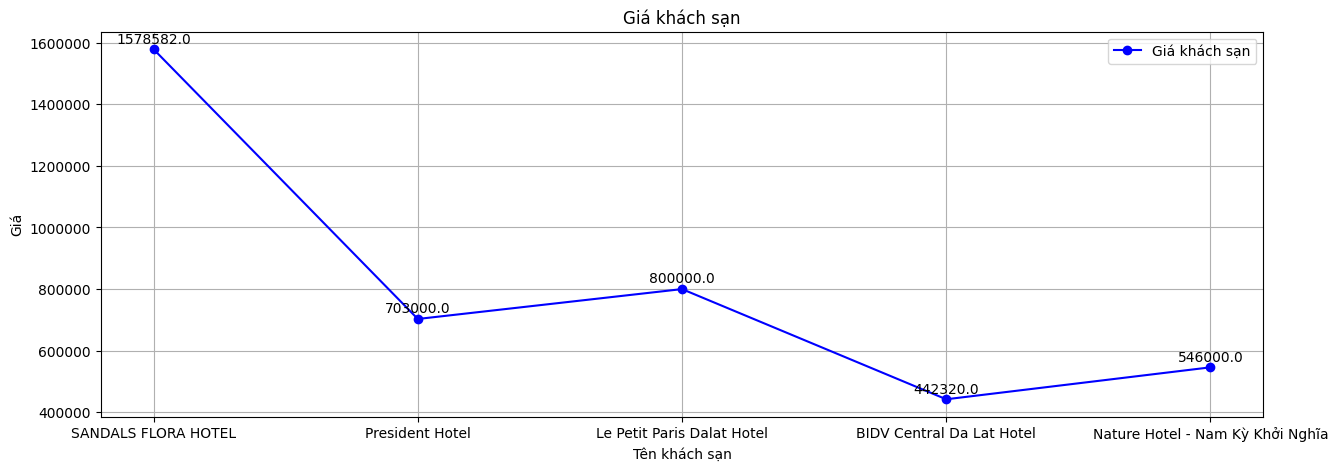

In [ ]:
plot_hotel_price(df_filtered)

# 6. Kết luận

Những đánh giá về kết quả

# **End Notebook**